In [3]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from arch import arch_model
import time
import os
import random
import tensorflow as tf
import torch

# For standalone NNs:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense

2026-06-12 11:36:44.796139: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Set random seeds for replication 
os.environ['PYTHONHASHSEED'] = '10'
random.seed(10)
np.random.seed(10)
tf.random.set_seed(10)
torch.manual_seed(10)

In [5]:
def set_random_seed(random_seed):
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)  # if use multi-GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    np.random.seed(random_seed)
    random.seed(random_seed)

In [6]:
set_random_seed(10)

In [7]:
#%run 01_utilities.ipynb
%run 01_utilities.ipynb

Error importing in API mode: ImportError("dlopen(/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): symbol not found in flat namespace '_R_BaseEnv'")
Trying to import in ABI mode.
/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/rpy2/rinterface/__init__.py:1185: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/Users/akirasohejl", R: "/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/MA_Code/Scripts/notebooks"
  warnings.warn(
/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/rpy2/rinterface/__init__.py:1185: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/hv/0fbbgwqj67sdm29fqsqv9bv80000gn/T//RtmpnoelcZ", R: "/var/folders/hv/0fbbgwqj67sdm29fqsqv9bv80000gn/T//RtmpfhsIry"
  warnings.warn(


In [8]:
# Set path
path = '/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/'

In [9]:
forecast_horizon = 100

# EGARCH Setup
egarch_scaling_factor = 1 # Necessary for the solver to converge under skewness

# Neural Network Setup
learning_rate = 0.001
batch_size = 32
epochs = 100
validation_split = 0.1

gamma = None

In [12]:
# Download data with yfinance
ticker = 'AAPL'
start_date = '2003-01-02'# '2020-01-01', '2024-01-02'
end_date = '2024-03-28'   #'2025-08-31'#'2025-03-28'

data = yf.download(ticker, start=start_date , end=end_date)
data['Close'] = data['Close']

# Calculate log returns
data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))

# Data preprocessing
returns = data['log_return'].dropna()

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: Timeout('Failed to perform, curl: (28) Operation timed out after 30001 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [9]:
# Test/Train Split
split_ratio = 0.8
returns = returns * 100
train_returns = returns[:int(len(returns)*split_ratio)]
train_sq_returns = train_returns**2

test_returns = returns[int(len(returns)*split_ratio):]
test_sq_returns = test_returns**2

train_index = train_returns.index
test_index = test_returns.index
train_returns

Date
2003-01-03    0.673111
2003-01-06    0.000000
2003-01-07   -0.335812
2003-01-08   -2.041229
2003-01-09    0.889734
                ...   
2019-12-19    0.100048
2019-12-20   -0.207317
2019-12-23    1.618656
2019-12-24    0.095025
2019-12-26    1.964596
Name: log_return, Length: 4275, dtype: float64

In [10]:
# Read in RV Data
capire_RV = pd.read_excel(path + "Data/Capire_March2024.xlsx", sheet_name = "RV", header = None)
capire_RV5 = pd.read_excel(path + "Data/Capire_March2024.xlsx", sheet_name = "RV_5", header = None)
companies = pd.read_excel(path + "Data/Capire_March2024.xlsx", sheet_name = "Companies", header = None)[0]
dates = pd.read_excel(path + "Data/Capire_March2024.xlsx", sheet_name = "Dates", header = None)[0]
RVs = {}
RVs_5 = {}
for c,comp in enumerate(companies):
    RVs[comp] = capire_RV.iloc[:,c]
    RVs[comp].index = dates
    
    RVs_5[comp]= capire_RV5.iloc[:,c]
    RVs_5[comp].index = dates
    

RVs_5['AAPL'].index = pd.to_datetime(RVs_5['AAPL'].index)


# Construct Train/Test Realized Variances
train_rv = RVs['AAPL'][:int(len(returns)*split_ratio)]
train_rv.index = pd.to_datetime(train_rv.index)
test_rv = RVs['AAPL'][int(len(returns)*split_ratio):]
test_rv.index = pd.to_datetime(test_rv.index)
test_rv = test_rv[1:-1] #[1:-19]

# Descriptive Statistics

In [11]:
returns.describe()

count    5344.000000
mean        0.124482
std         2.083091
min       -19.747005
25%        -0.868032
50%         0.109526
75%         1.194813
max        13.019400
Name: log_return, dtype: float64

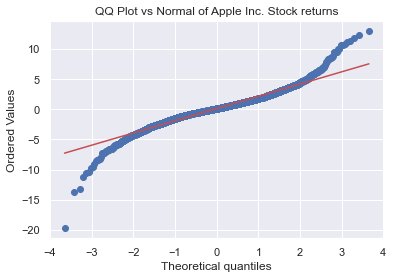

In [12]:
sns.set()
plot_qqs(returns, stock_name = "Apple Inc.")

In [13]:
# Descriptive Statistics
from scipy.stats import jarque_bera, skew, kurtosis
desc_stats = {
    "Mean": np.mean(returns),
    "Std Dev": np.std(returns, ddof=1),
    "Min": np.min(returns),
    "Max": np.max(returns),
    "Skewness": skew(returns),
    "Excess Kurtosis": kurtosis(returns, fisher=True)  # fisher=True → excess kurtosis
}

jb_stat, jb_p = jarque_bera(returns)
desc_stats["Jarque-Bera Stat"] = jb_stat
desc_stats["Jarque-Bera p-value"] = jb_p

print("\n=== Descriptive Statistics ===")
for k, v in desc_stats.items():
    print(f"{k:20}: {v:.4f}")


=== Descriptive Statistics ===
Mean                : 0.1245
Std Dev             : 2.0831
Min                 : -19.7470
Max                 : 13.0194
Skewness            : -0.1018
Excess Kurtosis     : 5.4962
Jarque-Bera Stat    : 6735.5467
Jarque-Bera p-value : 0.0000


In [14]:
df_desc_stats = pd.DataFrame(desc_stats.values(),index=desc_stats.keys()).reset_index()
df_desc_stats.columns = ["Statistic","Value"]
df_desc_stats

,Statistic,Value
0,Mean,0.124482
1,Std Dev,2.083091
2,Min,-19.747005
3,Max,13.019400
4,Skewness,-0.101824
5,Excess Kurtosis,5.496179
6,Jarque-Bera Stat,6735.546688
7,Jarque-Bera p-value,0.000000


In [15]:
df_desc_stats = pd.DataFrame(desc_stats.values(),index=desc_stats.keys()).T

In [16]:
print(df_desc_stats.to_latex(index=False,
                  formatters={"name": str.upper},
                  float_format="{:.2f}".format))

\begin{tabular}{rrrrrrrr}
\toprule
 Mean &  Std Dev &    Min &   Max &  Skewness &  Excess Kurtosis &  Jarque-Bera Stat &  Jarque-Bera p-value \\
\midrule
 0.12 &     2.08 & -19.75 & 13.02 &     -0.10 &             5.50 &           6735.55 &                 0.00 \\
\bottomrule
\end{tabular}



/var/folders/hv/0fbbgwqj67sdm29fqsqv9bv80000gn/T/ipykernel_75349/3635943456.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_desc_stats.to_latex(index=False,


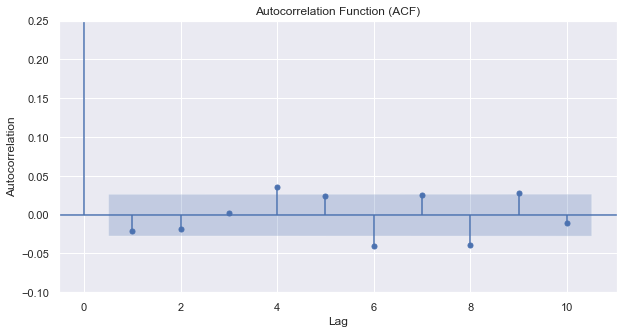

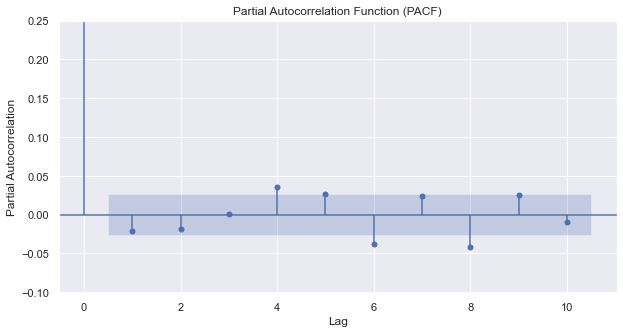

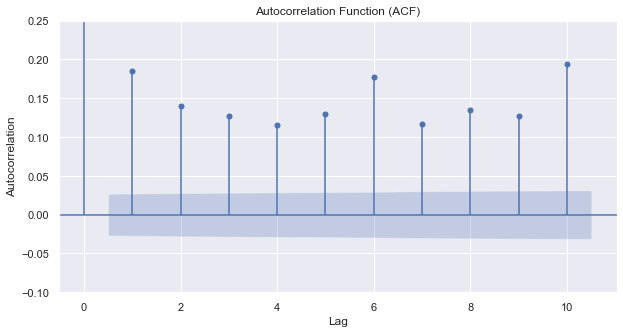

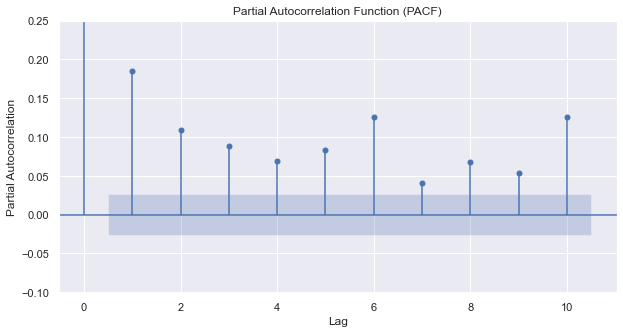

In [17]:
plot_acc(returns,lags = 10)

In [18]:
#acf_returns, ci_returns = sm.tsa.acf(returns, alpha=0.05)
#pacf_returns, ci_returns = sm.tsa.pacf(returns, alpha=0.05)
#acf_sq_returns, ci_sq_returns = sm.tsa.acf(returns**2, alpha=0.05)
#pacf_sq_returns, ci_sq_returns = sm.tsa.pacf(returns**2, alpha=0.05)

In [19]:
for lags in [1,5,10,20]:
    adf_returns = run_adf(returns, lags)
    print("\n=== Augmented Dickey–Fuller Test (Returns) ===")
    for k, v in adf_returns.items():
        print(f"{k:20}: {v}")
        

for lags in [1,5,10,20]:
    adf_sq = run_adf(returns**2, lags)
    print("\n=== Augmented Dickey–Fuller Test (Squared Returns) ===")
    for k, v in adf_sq.items():
        print(f"{k:20}: {v}")


=== Augmented Dickey–Fuller Test (Returns) ===
ADF Statistic       : -53.217829197539295
p-value             : 0.0
Lags used           : 1
Observations        : 5342
Critical values     : {'1%': -3.4315747182801055, '5%': -2.8620812006720593, '10%': -2.5670580804629393}

=== Augmented Dickey–Fuller Test (Returns) ===
ADF Statistic       : -29.836097166544487
p-value             : 0.0
Lags used           : 5
Observations        : 5338
Critical values     : {'1%': -3.431575636457688, '5%': -2.8620816063293675, '10%': -2.567058296408215}

=== Augmented Dickey–Fuller Test (Returns) ===
ADF Statistic       : -22.153396336358362
p-value             : 0.0
Lags used           : 10
Observations        : 5333
Critical values     : {'1%': -3.431576786117502, '5%': -2.862082114256976, '10%': -2.5670585667955033}

=== Augmented Dickey–Fuller Test (Returns) ===
ADF Statistic       : -14.981223678691862
p-value             : 1.1613292288247178e-27
Lags used           : 20
Observations        : 5323


In [20]:
for lags in [1,5,10,20]:
    kpss_returns = run_kpss_test(returns, regression='c',nlags = lags)
    print("\n=== KPSS Test (Returns) ===")
    for k, v in kpss_returns.items():
        print(f"{k:20}: {v}")

for lags in [1,5,10,20]:
    kpss_sq = run_kpss_test(returns**2, regression='c',nlags = lags)
    print("\n=== KPSS Test (Squared Returns) ===")
    for k, v in kpss_sq.items():
        print(f"{k:20}: {v}")


=== KPSS Test (Returns) ===
KPSS Statistic      : 0.33139913741145915
p-value             : 0.1
Lags used           : 1
Critical values     : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

=== KPSS Test (Returns) ===
KPSS Statistic      : 0.33317785029773056
p-value             : 0.1
Lags used           : 5
Critical values     : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

=== KPSS Test (Returns) ===
KPSS Statistic      : 0.3329129575141851
p-value             : 0.1
Lags used           : 10
Critical values     : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

=== KPSS Test (Returns) ===
KPSS Statistic      : 0.32266546267952306
p-value             : 0.1
Lags used           : 20
Critical values     : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

=== KPSS Test (Squared Returns) ===
KPSS Statistic      : 5.711769459782576
p-value             : 0.01
Lags used           : 1
Critical values     : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.73

/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(
/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(
/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(
/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range

In [21]:
engle_ng_results = engle_ng_sign_bias(returns)
print("\n=== Engle–Ng Sign Bias Tests ===")
print(engle_ng_results.to_string(index=False))


=== Engle–Ng Sign Bias Tests ===
              Test     t-Stat  p-Value
         Sign Bias  -0.291429 0.770734
Negative Size Bias -42.227209 0.000000
Positive Size Bias  40.986731 0.000000


In [22]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch


for lags in [1,5,10,20]:
    lb_returns = acorr_ljungbox(returns, lags=[lags], return_df=True, auto_lag = False)
    print("\n=== Ljung–Box Test: Returns ===")
    print(np.round(lb_returns,2))


for lags in [1,5,10,20]:
    # Ljung–Box test on Squared returns (ARCH effects)
    lb_sq_returns = acorr_ljungbox(returns**2, lags=[lags], return_df=True)
    print("\n=== Ljung–Box Test: Squared Returns ===")
    print(np.round(lb_sq_returns,2))



# ARCH LM test
for lags in [1,5,10,20]:
    arch_test = het_arch(returns,maxlag=lags,autolag = None)
    print("\n=== Engle's ARCH LM Test ===")
    print(f"LM Stat: {arch_test[0]:.6f}, p-value: {arch_test[1]:.6f}")


=== Ljung–Box Test: Returns ===
   lb_stat  lb_pvalue
1     2.46       0.12

=== Ljung–Box Test: Returns ===
   lb_stat  lb_pvalue
5    14.29       0.01

=== Ljung–Box Test: Returns ===
    lb_stat  lb_pvalue
10    39.14        0.0

=== Ljung–Box Test: Returns ===
    lb_stat  lb_pvalue
20    61.66        0.0

=== Ljung–Box Test: Squared Returns ===
   lb_stat  lb_pvalue
1   181.88        0.0

=== Ljung–Box Test: Squared Returns ===
   lb_stat  lb_pvalue
5   534.13        0.0

=== Ljung–Box Test: Squared Returns ===
    lb_stat  lb_pvalue
10   1159.6        0.0

=== Ljung–Box Test: Squared Returns ===
    lb_stat  lb_pvalue
20  1563.65        0.0

=== Engle's ARCH LM Test ===
LM Stat: 181.745510, p-value: 0.000000

=== Engle's ARCH LM Test ===
LM Stat: 341.810192, p-value: 0.000000

=== Engle's ARCH LM Test ===
LM Stat: 541.989383, p-value: 0.000000

=== Engle's ARCH LM Test ===
LM Stat: 550.891542, p-value: 0.000000


/var/folders/hv/0fbbgwqj67sdm29fqsqv9bv80000gn/T/ipykernel_75349/4014672200.py:20: FutureWarning: the 'maxlag'' keyword is deprecated, use 'nlags' instead.
  arch_test = het_arch(returns,maxlag=lags,autolag = None)


# GARCH

In [23]:
arch_model(train_returns, mean='Zero', vol='GARCH', p=1, q=1).fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 2447592156.0063114
Iteration:      2,   Func. Count:     12,   Neg. LLF: 11230.339043283751
Iteration:      3,   Func. Count:     18,   Neg. LLF: 8891.702386691668
Iteration:      4,   Func. Count:     23,   Neg. LLF: 10473.503715445127
Iteration:      5,   Func. Count:     28,   Neg. LLF: 8868.789891620789
Iteration:      6,   Func. Count:     33,   Neg. LLF: 8853.6679536389
Iteration:      7,   Func. Count:     37,   Neg. LLF: 8853.463972382026
Iteration:      8,   Func. Count:     41,   Neg. LLF: 8853.44933177701
Iteration:      9,   Func. Count:     45,   Neg. LLF: 8853.428978751537
Iteration:     10,   Func. Count:     49,   Neg. LLF: 8853.425778367255
Iteration:     11,   Func. Count:     53,   Neg. LLF: 8853.422898449026
Iteration:     12,   Func. Count:     57,   Neg. LLF: 8853.422765761896
Iteration:     13,   Func. Count:     61,   Neg. LLF: 8853.422760499503
Iteration:     14,   Func. Count:     64,   Neg. LLF: 8853.42276

                       Zero Mean - GARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8853.42
Distribution:                  Normal   AIC:                           17712.8
Method:            Maximum Likelihood   BIC:                           17731.9
                                        No. Observations:                 4275
Date:                 Sa, Okt 11 2025   Df Residuals:                     4275
Time:                        13:19:57   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0470  3.174e-02      1.482      0.138  [-

In [24]:
garch = arch_model(returns, mean='Zero', vol='GARCH', p=1, q=1).fit()
forecast_horizon = 100#len(test_returns)
garch_preds_origin = garch.forecast(horizon=forecast_horizon, 
                             start= train_returns.index[-1],   
                             reindex=True,
                             align="origin").variance

garch_preds_target = garch.forecast(horizon=forecast_horizon, 
                             start= train_returns.index[-1],   
                             reindex=True,
                             align="target").variance

garch_one_step_preds = garch_preds_target.loc[test_index,"h.001"]

Iteration:      1,   Func. Count:      5,   Neg. LLF: 3043191392.7615294
Iteration:      2,   Func. Count:     12,   Neg. LLF: 13997.538765693304
Iteration:      3,   Func. Count:     18,   Neg. LLF: 11085.604163151489
Iteration:      4,   Func. Count:     23,   Neg. LLF: 12619.311258450653
Iteration:      5,   Func. Count:     28,   Neg. LLF: 11044.079328111384
Iteration:      6,   Func. Count:     33,   Neg. LLF: 11024.571945467902
Iteration:      7,   Func. Count:     37,   Neg. LLF: 11024.52747313781
Iteration:      8,   Func. Count:     41,   Neg. LLF: 11024.521007632764
Iteration:      9,   Func. Count:     45,   Neg. LLF: 11024.52002480975
Iteration:     10,   Func. Count:     49,   Neg. LLF: 11024.519991118446
Iteration:     11,   Func. Count:     53,   Neg. LLF: 11024.519990210396
Optimization terminated successfully    (Exit mode 0)
            Current function value: 11024.519990210396
            Iterations: 11
            Function evaluations: 53
            Gradient evalu

In [25]:
garch_parameters = pd.DataFrame(np.round([[garch.params[0],
                garch.params[1],
                garch.params[2]]],4),
                           columns = ["Omega","Alpha","Beta"])
garch_parameters

,Omega,Alpha,Beta
0,0.067,0.0615,0.9237


In [26]:
# Unconditional Variance Estimate: omega/() 
uncond_variance = np.round(garch_parameters.Omega/(1 - garch_parameters.Alpha - garch_parameters.Beta),2)[0]
uncond_variance    

4.53

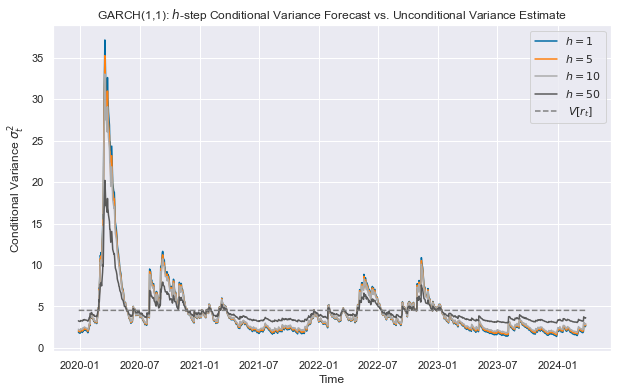

In [27]:
sns.set()
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("GARCH(1,1): $h$-step Conditional Variance Forecast vs. Unconditional Variance Estimate")
plt.plot(garch_preds_origin['h.001'], label = "$h=1$")
plt.plot(garch_preds_origin['h.005'], label = "$h=5$")
plt.plot(garch_preds_origin['h.010'], label = "$h=10$")
plt.plot(garch_preds_origin['h.050'], label = "$h=50$")
plt.plot(test_index,np.repeat(uncond_variance,len(test_returns)),linestyle = "dashed", color = "grey", label = " $V[r_t]$")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/garch_uncond_var.png")

In [28]:
# Multi-Step predictions
garch_n_step_qlikes_rsq = []
garch_n_step_rmse_rsq = []

garch_n_step_qlikes_rv = []
garch_n_step_rmse_rv = []

for i in range(1,forecast_horizon +1):
    garch_preds = garch_preds_target.loc[test_index,f"h.{i:03}"].dropna()
    y_test = test_sq_returns.loc[garch_preds.index]
    y_test_rv = test_rv.loc[garch_preds.index]
    
    garch_n_step_qlikes_rsq.append(np.mean(np.log(garch_preds) + (y_test) / (garch_preds)))
    garch_n_step_rmse_rsq.append(np.sqrt(mean_squared_error(y_test, garch_preds)))
    
    garch_n_step_qlikes_rv.append(np.mean(np.log(garch_preds) + (y_test_rv) / (garch_preds)))
    garch_n_step_rmse_rv.append(np.sqrt(mean_squared_error(y_test_rv, garch_preds)))

In [29]:
garch_origin_qlikes_rsq,garch_origin_qlikes_rv,garch_origin_rmse_rsq,garch_origin_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = garch_preds_origin.loc[test_index,:],
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [2.08 2.31 1.86 2.03]
RMSE Losses: 
 [ 9.99 11.    3.88  3.94]


# EGARCH(1,1)

In [30]:
egarch_model = egarch_fit(train_returns,scaling_factor =1)

R callback write-console: Lade nötiges Paket: parallel
  
R callback write-console: 
Attache Paket: ‘rugarch’

  
R callback write-console: Das folgende Objekt ist maskiert ‘package:stats’:

    sigma

  



*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: eGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.158101    0.024356   6.4913        0
omega   0.038175    0.002438  15.6581        0
alpha1 -0.059230    0.007738  -7.6547        0
beta1   0.976523    0.000979 997.7382        0
gamma1  0.140147    0.012578  11.1426        0

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.158101    0.026841    5.8902    0e+00
omega   0.038175    0.003159   12.0831    0e+00
alpha1 -0.059230    0.013891   -4.2638    2e-05
beta1   0.976523    0.000690 1416.1336    0e+00
gamma1  0.140147    0.022063    6.3521    0e+00

LogLikelihood : -8784.217 

Information Criteria
------------------------------------
         

In [31]:
egarch_parameters = pd.DataFrame([np.round([np.float(egarch_model.split("\n")[15].split(" ")[3]),
                     np.float(egarch_model.split("\n")[18].split(" ")[2]),
                     np.float(egarch_model.split("\n")[17].split(" ")[3]),
                     np.float(egarch_model.split("\n")[16].split(" ")[1])],4)],
                    columns = ["Omega","Alpha","Beta","Gamma"])
egarch_parameters

/var/folders/hv/0fbbgwqj67sdm29fqsqv9bv80000gn/T/ipykernel_75349/778110917.py:1: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  egarch_parameters = pd.DataFrame([np.round([np.float(egarch_model.split("\n")[15].split(" ")[3]),
/var/folders/hv/0fbbgwqj67sdm29fqsqv9bv80000gn/T/ipykernel_75349/778110917.py:2: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#dep

,Omega,Alpha,Beta,Gamma
0,0.0382,0.1401,0.9765,-0.0592


In [32]:
egarch_preds_target = egarch_multistep_forecast_target(train_returns,
                                                           test_returns, 
                                                           scaling_factor = 1,
                                                           forecast_horizon = forecast_horizon)
egarch_one_step_preds = egarch_preds_target.iloc[:,0]
#egarch_onestep_target_qlikes.append(np.mean(np.log(egarch_preds) + test_returns / egarch_preds))

In [33]:
egarch_preds_origin = egarch_multistep_forecast(train_returns,
                                                           test_returns, 
                                                           scaling_factor = 1,
                                                           forecast_horizon = forecast_horizon)

In [34]:
egarch_origin_qlikes_rsq,egarch_origin_qlikes_rv,egarch_origin_rmse_rsq,egarch_origin_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = egarch_preds_origin,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [2.11 2.47 1.87 2.21]
RMSE Losses: 
 [ 9.99 11.44  3.49  5.02]


In [35]:
uncond_var_egarch = np.exp(egarch_parameters['Omega']/(1-egarch_parameters['Beta']))
uncond_var_egarch = np.round(uncond_var_egarch[0]/egarch_scaling_factor**2,2)
uncond_var_egarch

5.08

In [36]:
egarch_n_step_origin = egarch_multistep_forecast(train_returns,test_returns, scaling_factor = 1)

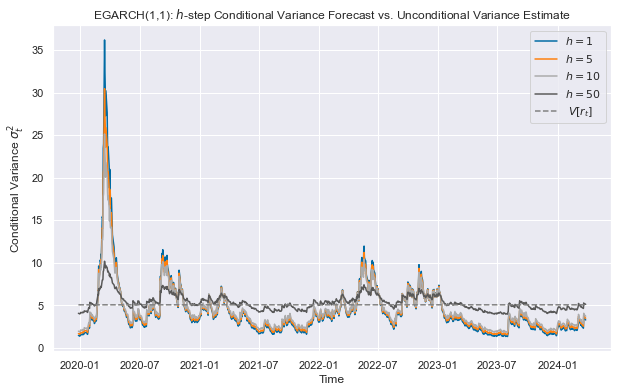

In [37]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("EGARCH(1,1): $h$-step Conditional Variance Forecast vs. Unconditional Variance Estimate")
plt.plot(egarch_n_step_origin['h.001'], label = "$h=1$")
plt.plot(egarch_n_step_origin['h.005'], label = "$h=5$")
plt.plot(egarch_n_step_origin['h.010'], label = "$h=10$")
plt.plot(egarch_n_step_origin['h.050'], label = "$h=50$")
plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey", label = " $V[r_t]$")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/egarch_uncond_var.png")

# Neural Networks

## MLP

In [38]:
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp, scaler_x_mlp, scaler_y_mlp = train_test_split(return_input = returns, 
                                                                                        split_ratio = 0.8, 
                                                                                        scaling = True,
                                                                                        scaler = "Standard",
                                                                                        reshape_dim = 2)

In [39]:
# Define Vanilla MLP
model_mlp = Sequential([
    Dense(16, activation='relu', input_shape=(1,)),
    Dense(8, activation='relu'),
    Dense(1, activation= 'softplus')  # guarantees positive output
])
optimizer = Adam(learning_rate= learning_rate) # Default is 0.001
model_mlp.compile(optimizer=optimizer, loss= gaussian_nll)
loss_history_nn_mlp = model_mlp.fit(X_train_mlp, 
                                    y_train_mlp, 
                                    epochs=epochs, 
                                    batch_size=batch_size, 
                                    validation_split= validation_split)

Epoch 1/100


/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 173.6486 - val_loss: 0.1505
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.5631 - val_loss: 0.1421
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1202 - val_loss: 0.1356
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.6872 - val_loss: 0.1303
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2944 - val_loss: 0.1274
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.9513 - val_loss: 0.1255
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6566 - val_loss: 0.1243
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4057 - val_loss: 0.1235
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1922 - val_loss: 0.1231
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0103 - val_loss: 0.1227
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8548 - val_loss: 0.1225
Epoch 12/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/st

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - loss: 0.5992 - val_loss: 0.1263
Epoch 69/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 0.5966 - val_loss: 0.1266
Epoch 70/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - loss: 0.5938 - val_loss: 0.1267
Epoch 71/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5916 - val_loss: 0.1269
Epoch 72/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5887 - val_loss: 0.1272
Epoch 73/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5868 - val_loss: 0.1274
Epoch 74/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5840 - val_loss: 0.1276
Epoch 75/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5817 - val_loss: 0.1278
Epoch 76/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - loss: 0.5795 - val_loss: 0.1280
Epoch 77/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5771 - val_loss: 0.1282
Epoch 78/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5752 - val_loss: 0.1283
Epoch 79/100
121/121 ━━━━━━━━━━━━━━━━

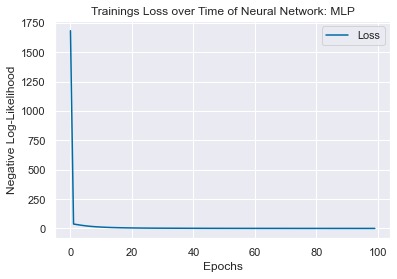

In [40]:
plot_loss(model_name = "Neural Network: MLP",
          loss = loss_history_nn_mlp.history['loss'],
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [41]:
save_loss(loss_list = loss_history_nn_mlp.history['loss'],
          model_name = "nn_mlp")

In [42]:
y_pred_nn_mlp_scaled = model_mlp.predict(X_test_mlp)
y_pred_nn_mlp = scaler_y_mlp.inverse_transform(y_pred_nn_mlp_scaled).flatten()#/100 # scale back
y_test_true = y_test_mlp.flatten()

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [43]:
gamma = None

In [44]:
n_step_qlikes_mlp_nll, n_step_preds_mlp = nn_multi_step_preds(model_mlp,
                                            test_returns, 
                                            X_test_mlp, 
                                            scaler_y_mlp,
                                            H=100,
                                            model_name = "MLP")

Forecast Horizon: 1
Forecast Horizon: 2
Forecast Horizon: 3
Forecast Horizon: 4
Forecast Horizon: 5
Forecast Horizon: 6
Forecast Horizon: 7
Forecast Horizon: 8
Forecast Horizon: 9
Forecast Horizon: 10
Forecast Horizon: 11
Forecast Horizon: 12
Forecast Horizon: 13
Forecast Horizon: 14
Forecast Horizon: 15
Forecast Horizon: 16
Forecast Horizon: 17
Forecast Horizon: 18
Forecast Horizon: 19
Forecast Horizon: 20
Forecast Horizon: 21
Forecast Horizon: 22
Forecast Horizon: 23
Forecast Horizon: 24
Forecast Horizon: 25
Forecast Horizon: 26
Forecast Horizon: 27
Forecast Horizon: 28
Forecast Horizon: 29
Forecast Horizon: 30
Forecast Horizon: 31
Forecast Horizon: 32
Forecast Horizon: 33
Forecast Horizon: 34
Forecast Horizon: 35
Forecast Horizon: 36
Forecast Horizon: 37
Forecast Horizon: 38
Forecast Horizon: 39
Forecast Horizon: 40
Forecast Horizon: 41
Forecast Horizon: 42
Forecast Horizon: 43
Forecast Horizon: 44
Forecast Horizon: 45
Forecast Horizon: 46
Forecast Horizon: 47
Forecast Horizon: 48
F

In [45]:
mlp_qlikes_rsq,mlp_qlikes_rv,mlp_rmse_rsq,mlp_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = n_step_preds_mlp,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [2.77 2.94 2.66 2.83]
RMSE Losses: 
 [13.15 14.97  9.65 11.97]


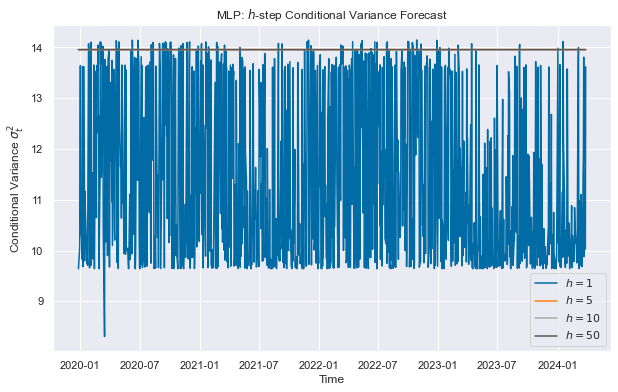

In [46]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("MLP: $h$-step Conditional Variance Forecast")
plt.plot(n_step_preds_mlp['h.001'], label = "$h=1$")
plt.plot(n_step_preds_mlp['h.005'], label = "$h=5$")
plt.plot(n_step_preds_mlp['h.010'], label = "$h=10$")
plt.plot(n_step_preds_mlp['h.050'], label = "$h=50$")
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/mlp_uncond_var.png")

## LSTM

In [47]:
%run 01_utilities.ipynb

In [48]:
"""
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, scaler_x_lstm, scaler_y_lstm = train_test_split(return_input = returns,#[:5300], 
                                                                                            split_ratio = 0.8, 
                                                                                            scaling = True,
                                                                                            scaler = "Standard",
                                                                                            reshape_dim = 3)
"""                                                                                            
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, scaler_x_lstm, scaler_y_lstm = train_test_split_lstm(return_input = returns, 
                                                                                            split_ratio = 0.8, 
                                                                                            scaling = True,
                                                                                            scaler = "Standard",
                                                                                            win =1)

In [49]:
# Define Vanilla LSTM Model
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential([
    LSTM(16, input_shape=(1, 1)),  # 1 time step, 1 feature
    Dense(8, activation='relu'),
    Dense(1, activation='softplus')  # ensures non-negative output
])

model_lstm.compile(optimizer=Adam(learning_rate= learning_rate), loss='mse')
loss_history_nn_lstm =  model_lstm.fit(X_train_lstm, 
                                       y_train_lstm, 
                                       epochs= epochs, 
                                       batch_size=batch_size, 
                                       validation_split= validation_split)

# Predict and unscale
y_pred_nn_lstm_scaled = model_lstm.predict(X_test_lstm)
y_pred_nn_lstm = scaler_y_lstm.inverse_transform(y_pred_nn_lstm_scaled).flatten()

Epoch 1/100


/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.5357 - val_loss: 0.6861
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2577 - val_loss: 0.5127
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1707 - val_loss: 0.4791
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1571 - val_loss: 0.4695
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1536 - val_loss: 0.4657
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1523 - val_loss: 0.4633
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1517 - val_loss: 0.4622
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1513 - val_loss: 0.4614
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1510 - val_loss: 0.4609
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1508 - val_loss: 0.4607
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1507 - val_loss: 0.4609
Epoch 12/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

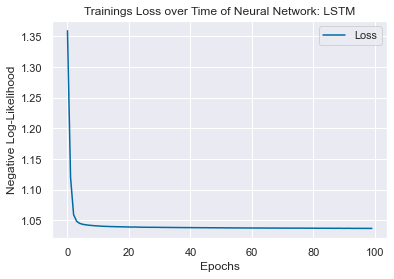

In [50]:
plot_loss(model_name = "Neural Network: LSTM",
          loss = loss_history_nn_lstm.history['loss'],
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [51]:
def save_loss(loss_list,model_name, path = "/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Loss/"):
    pd.Series(loss_list).to_csv(path+model_name+"_loss_history.csv", index = False, header = False)

In [52]:
save_loss(loss_list = loss_history_nn_lstm.history['loss'],
          model_name = "nn_lstm")

In [53]:
n_step_qlikes_lstm, lstm_n_step_preds = lstm_multi_step_preds(model_lstm,test_returns, 
                                             X_test_lstm, 
                                             scaler_y = scaler_y_lstm,
                                             scaler_x = scaler_x_lstm,
                                             gamma = None,
                                             H=forecast_horizon,
                                             model_name = "LSTM",
                                             path = path)

Forecast: 1
Forecast: 2
Forecast: 3
Forecast: 4
Forecast: 5
Forecast: 6
Forecast: 7
Forecast: 8
Forecast: 9
Forecast: 10
Forecast: 11
Forecast: 12
Forecast: 13
Forecast: 14
Forecast: 15
Forecast: 16
Forecast: 17
Forecast: 18
Forecast: 19
Forecast: 20
Forecast: 21
Forecast: 22
Forecast: 23
Forecast: 24
Forecast: 25
Forecast: 26
Forecast: 27
Forecast: 28
Forecast: 29
Forecast: 30
Forecast: 31
Forecast: 32
Forecast: 33
Forecast: 34
Forecast: 35
Forecast: 36
Forecast: 37
Forecast: 38
Forecast: 39
Forecast: 40
Forecast: 41
Forecast: 42
Forecast: 43
Forecast: 44
Forecast: 45
Forecast: 46
Forecast: 47
Forecast: 48
Forecast: 49
Forecast: 50
Forecast: 51
Forecast: 52
Forecast: 53
Forecast: 54
Forecast: 55
Forecast: 56
Forecast: 57
Forecast: 58
Forecast: 59
Forecast: 60
Forecast: 61
Forecast: 62
Forecast: 63
Forecast: 64
Forecast: 65
Forecast: 66
Forecast: 67
Forecast: 68
Forecast: 69
Forecast: 70
Forecast: 71
Forecast: 72
Forecast: 73
Forecast: 74
Forecast: 75
Forecast: 76
Forecast: 77
Forecast

In [54]:
lstm_qlikes_rsq,lstm_qlikes_rv,lstm_rmse_rsq,lstm_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = lstm_n_step_preds,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [2.4  2.46 2.06 2.1 ]
RMSE Losses: 
 [11.06 11.45  3.97  4.39]


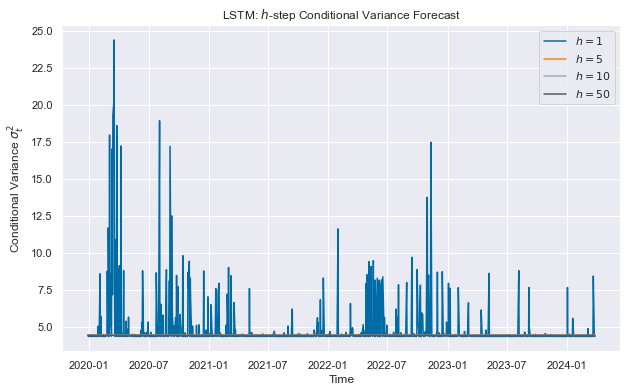

In [55]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("LSTM: $h$-step Conditional Variance Forecast")
plt.plot(lstm_n_step_preds['h.001'], label = "$h=1$")
plt.plot(lstm_n_step_preds['h.005'], label = "$h=5$")
plt.plot(lstm_n_step_preds['h.010'], label = "$h=10$")
plt.plot(lstm_n_step_preds['h.050'], label = "$h=50$")
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/lstm_uncond_var.png")

# Hybrid-Models

In [56]:
%run 02_augmented_architecture.ipynb

## 1.1 Augmented Hybrid-Model: Donaldson Approach

In [57]:
start = time.time()
augmented_model, train_losses_aug_donald = train_augmented_model(train_returns, epochs= epochs)
end = time.time()
print("Computation time for model estimation:",end - start, "seconds")

Epoch 000 | Loss: 118.387047
Epoch 001 | Loss: 89.236221
Epoch 002 | Loss: 74.724236
Epoch 003 | Loss: 65.708794
Epoch 004 | Loss: 59.438480
Epoch 005 | Loss: 54.766941
Epoch 006 | Loss: 51.121731
Epoch 007 | Loss: 48.181320
Epoch 008 | Loss: 45.749382
Epoch 009 | Loss: 43.698376
Epoch 010 | Loss: 41.941345
Epoch 011 | Loss: 40.416676
Epoch 012 | Loss: 39.079311
Epoch 013 | Loss: 37.895462
Epoch 014 | Loss: 36.839153
Epoch 015 | Loss: 35.890118
Epoch 016 | Loss: 35.032223
Epoch 017 | Loss: 34.252464
Epoch 018 | Loss: 33.540234
Epoch 019 | Loss: 32.886757
Epoch 020 | Loss: 32.284744
Epoch 021 | Loss: 31.728033
Epoch 022 | Loss: 31.211432
Epoch 023 | Loss: 30.730478
Epoch 024 | Loss: 30.281349
Epoch 025 | Loss: 29.860743
Epoch 026 | Loss: 29.465792
Epoch 027 | Loss: 29.093985
Epoch 028 | Loss: 28.743111
Epoch 029 | Loss: 28.411243
Epoch 030 | Loss: 28.096664
Epoch 031 | Loss: 27.797852
Epoch 032 | Loss: 27.513453
Epoch 033 | Loss: 27.242264
Epoch 034 | Loss: 26.983198
Epoch 035 | Loss: 2

In [251]:
augmented_model._parameters

OrderedDict([('omega',
              Parameter containing:
              tensor(0.3262, requires_grad=True)),
             ('alpha',
              Parameter containing:
              tensor([0.5910], requires_grad=True)),
             ('beta',
              Parameter containing:
              tensor([1.2910], requires_grad=True)),
             ('zeta',
              Parameter containing:
              tensor([0.2193, 0.2146, 0.2216, 0.2125, 0.2350, 0.2238, 0.2183, 0.2165, 0.2150,
                      0.2462], requires_grad=True)),
             ('lambda_hdw',
              Parameter containing:
              tensor([[[-0.0479, -0.4425]],
              
                      [[-0.4313, -0.4499]],
              
                      [[-0.4892, -0.4657]],
              
                      [[-0.3788, -0.4510]],
              
                      [[-0.4690,  0.2192]],
              
                      [[ 0.3067,  0.3379]],
              
                      [[ 0.2694,  0.1694]],


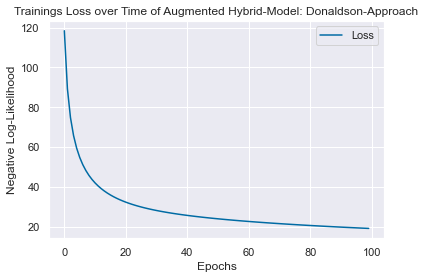

In [58]:
plot_loss(model_name = "Augmented Hybrid-Model: Donaldson-Approach",
          loss = train_losses_aug_donald,
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [59]:
save_loss(loss_list = train_losses_aug_donald,
          model_name = "aug_donald")

In [60]:
# Predict with Augmented Model
test_tensor = torch.tensor((test_returns.values).flatten()).float()
with torch.no_grad():
    augmented_preds = augmented_model(test_tensor, test_tensor ** 2)
    vol = torch.sqrt(augmented_preds).detach().numpy()

In [61]:
print("Estimated Omega:",augmented_model.omega.detach().numpy())
print("Estimated Alpha:",augmented_model.alpha.detach().numpy()[0])
print("Estimated Beta:",augmented_model.beta.detach().numpy()[0])
print("Estimated NN-Adjust mean(Zeta):",np.mean(augmented_model.zeta.detach().numpy()), ": coefficients for sigmoid basis functions")
print("Estimated NN Adjust mean(Lambda):",np.mean(augmented_model.lambda_hdw.detach().numpy()), ": fixed random weights for sigmoid arguments")

Estimated Omega: 0.3261852
Estimated Alpha: 0.59095657
Estimated Beta: 1.2909566
Estimated NN-Adjust mean(Zeta): 0.22227366 : coefficients for sigmoid basis functions
Estimated NN Adjust mean(Lambda): -0.06893273 : fixed random weights for sigmoid arguments


In [62]:
augmented_model.zeta.detach().numpy()

array([0.21933866, 0.21457626, 0.22155324, 0.21250708, 0.23495743,
       0.22381747, 0.21825059, 0.21650718, 0.2149817 , 0.24624714],
      dtype=float32)

In [63]:
aug_donaldson_parameters = pd.DataFrame([[augmented_model.omega.detach().numpy(),
                                         augmented_model.alpha.detach().numpy()[0],
                                         augmented_model.beta.detach().numpy()[0],
                                         np.mean(augmented_model.zeta.detach().numpy())]],
                                       columns = ["Omega","Alpha","Beta","NN_Adjust"])
aug_donaldson_parameters

,Omega,Alpha,Beta,NN_Adjust
0,0.3261852,0.590957,1.290957,0.222274


In [64]:
n_step_qlikes_aug_donald,n_step_preds_aug_donald = multi_step_preds_torch(model = augmented_model,
                                                      model_name = "aug_donald",
                                                       test_returns = test_returns,
                                                       H = forecast_horizon)

Forecast Horizon: 1
Forecast Horizon: 2
Forecast Horizon: 3
Forecast Horizon: 4
Forecast Horizon: 5
Forecast Horizon: 6
Forecast Horizon: 7
Forecast Horizon: 8
Forecast Horizon: 9
Forecast Horizon: 10
Forecast Horizon: 11
Forecast Horizon: 12
Forecast Horizon: 13
Forecast Horizon: 14
Forecast Horizon: 15
Forecast Horizon: 16
Forecast Horizon: 17
Forecast Horizon: 18
Forecast Horizon: 19
Forecast Horizon: 20
Forecast Horizon: 21
Forecast Horizon: 22
Forecast Horizon: 23
Forecast Horizon: 24
Forecast Horizon: 25
Forecast Horizon: 26
Forecast Horizon: 27
Forecast Horizon: 28
Forecast Horizon: 29
Forecast Horizon: 30
Forecast Horizon: 31
Forecast Horizon: 32
Forecast Horizon: 33
Forecast Horizon: 34
Forecast Horizon: 35
Forecast Horizon: 36
Forecast Horizon: 37
Forecast Horizon: 38
Forecast Horizon: 39
Forecast Horizon: 40
Forecast Horizon: 41
Forecast Horizon: 42
Forecast Horizon: 43
Forecast Horizon: 44
Forecast Horizon: 45
Forecast Horizon: 46
Forecast Horizon: 47
Forecast Horizon: 48
F

In [65]:
aug_don_qlikes_rsq,aug_don_qlikes_rv,aug_don_rmse_rsq,aug_don_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = n_step_preds_aug_donald,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [ 2.62 26.45  2.14 26.45]
RMSE Losses: 
 [2.14000000e+01 2.46265509e+12 2.05900000e+01 2.46265509e+12]


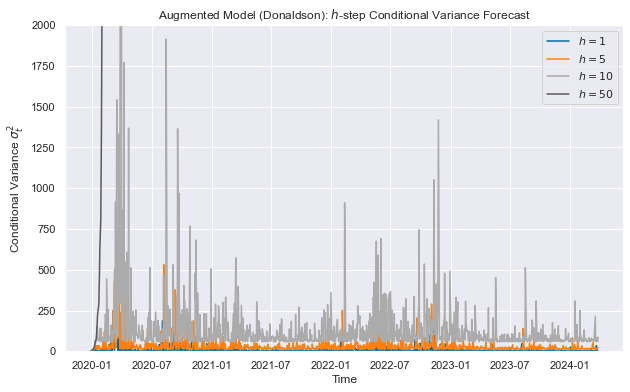

In [66]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("Augmented Model (Donaldson): $h$-step Conditional Variance Forecast")
plt.plot(n_step_preds_aug_donald['h.001'], label = "$h=1$")
plt.plot(n_step_preds_aug_donald['h.005'], label = "$h=5$")
plt.plot(n_step_preds_aug_donald['h.010'], label = "$h=10$")
plt.plot(n_step_preds_aug_donald['h.050'], label = "$h=50$",alpha=1)
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.ylim(0,2000)
plt.savefig(path + f"Plots/DataApp/Preds/aug_don_uncond_var.png")

## 1.2 Augmented Hybrid-Model: Extended Approach (MLP)

In [67]:
%run 02_augmented_architecture.ipynb

In [68]:
aug_extended_mlp, loss_history_aug_mlp, aug_mlp_params, learned_garch_params  = run_joint_training(aug_model = AugmentedModel_Extended_mlp(),
                                                                  returns_series = train_returns,
                                                                  epochs= epochs)
   
with torch.no_grad():
    aug_ext_qlikes,n_step_preds_aug_ext_mlp = lower_triangular_from_workflow(
        net=aug_extended_mlp,
        model_name = "aug_ext_mlp",
        garch_param_module=learned_garch_params,
        test_returns=test_returns,
        H=forecast_horizon
    )

Epoch 000 | Loss: 6043.562012 | ω=0.0954, α=0.1001, β=0.7201, α+β=0.8202 | NN mean weights: {'fc1.weight': 0.0895, 'fc2.weight': -0.0744} | NN adjust: -0.43877909
Epoch 001 | Loss: 5947.346680 | ω=0.0955, α=0.1002, β=0.7201, α+β=0.8203 | NN mean weights: {'fc1.weight': 0.0894, 'fc2.weight': -0.0739} | NN adjust: -0.43553624
Epoch 002 | Loss: 5879.985840 | ω=0.0955, α=0.1002, β=0.7202, α+β=0.8204 | NN mean weights: {'fc1.weight': 0.0892, 'fc2.weight': -0.0734} | NN adjust: -0.43328327
Epoch 003 | Loss: 5824.880859 | ω=0.0956, α=0.1003, β=0.7202, α+β=0.8205 | NN mean weights: {'fc1.weight': 0.0891, 'fc2.weight': -0.0729} | NN adjust: -0.43134341
Epoch 004 | Loss: 5754.145996 | ω=0.0956, α=0.1003, β=0.7203, α+β=0.8206 | NN mean weights: {'fc1.weight': 0.089, 'fc2.weight': -0.0725} | NN adjust: -0.42952788
Epoch 005 | Loss: 5574.866699 | ω=0.0957, α=0.1003, β=0.7204, α+β=0.8207 | NN mean weights: {'fc1.weight': 0.0889, 'fc2.weight': -0.072} | NN adjust: -0.42790112
Epoch 006 | Loss: 5524.9

Epoch 051 | Loss: 2698.052002 | ω=0.0990, α=0.1034, β=0.7221, α+β=0.8255 | NN mean weights: {'fc1.weight': 0.0805, 'fc2.weight': -0.0473} | NN adjust: -0.31018490
Epoch 052 | Loss: 2667.804199 | ω=0.0991, α=0.1035, β=0.7221, α+β=0.8256 | NN mean weights: {'fc1.weight': 0.0804, 'fc2.weight': -0.0469} | NN adjust: -0.30800965
Epoch 053 | Loss: 2621.726318 | ω=0.0991, α=0.1035, β=0.7221, α+β=0.8256 | NN mean weights: {'fc1.weight': 0.0803, 'fc2.weight': -0.0465} | NN adjust: -0.30600837
Epoch 054 | Loss: 2610.073975 | ω=0.0992, α=0.1036, β=0.7221, α+β=0.8257 | NN mean weights: {'fc1.weight': 0.0802, 'fc2.weight': -0.0461} | NN adjust: -0.30417299
Epoch 055 | Loss: 2502.740479 | ω=0.0992, α=0.1036, β=0.7221, α+β=0.8257 | NN mean weights: {'fc1.weight': 0.0801, 'fc2.weight': -0.0458} | NN adjust: -0.30245882
Epoch 056 | Loss: 2438.675049 | ω=0.0992, α=0.1036, β=0.7222, α+β=0.8258 | NN mean weights: {'fc1.weight': 0.08, 'fc2.weight': -0.0455} | NN adjust: -0.30079818
Epoch 057 | Loss: 2401.3

In [70]:
aug_extended_mlp_parameters = pd.DataFrame([[float(aug_mlp_params[0].detach().numpy()),
                                            float(aug_mlp_params[1].detach().numpy()),
                                            float(aug_mlp_params[2].detach().numpy()),
                                            float(aug_mlp_params[3].detach().numpy())]],
                                           columns = ["Omega","Alpha","Beta","NN_Adjust"])
aug_extended_mlp_parameters

,Omega,Alpha,Beta,NN_Adjust
0,0.101429,0.105438,0.722881,-0.223361


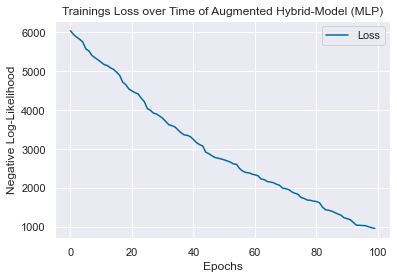

In [71]:
plot_loss(model_name = "Augmented Hybrid-Model (MLP)",
          loss = loss_history_aug_mlp,
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [72]:
save_loss(loss_list = loss_history_aug_mlp,
          model_name = "aug_extended_mlp")

In [140]:
aug_mlp_qlikes_rsq,aug_mlp_qlikes_rv,aug_mlp_rmse_rsq,aug_mlp_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = n_step_preds_aug_ext_mlp,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon,
                                                                                             decimal = 2)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [  19780.3  4310394.23   88988.9  2675243.68]
RMSE Losses: 
 [ 9.64 12.23  2.8   4.82]


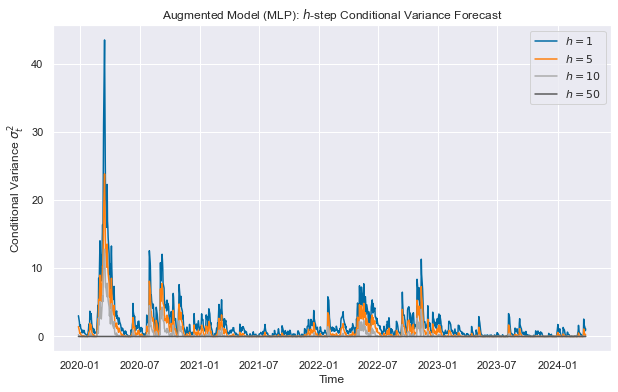

In [74]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("Augmented Model (MLP): $h$-step Conditional Variance Forecast")
plt.plot(n_step_preds_aug_ext_mlp['h.001'], label = "$h=1$")
plt.plot(n_step_preds_aug_ext_mlp['h.005'], label = "$h=5$")
plt.plot(n_step_preds_aug_ext_mlp['h.010'], label = "$h=10$")
plt.plot(n_step_preds_aug_ext_mlp['h.050'], label = "$h=50$",alpha=1)
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/aug_mlp_uncond_var.png")

## 1.3 Augmented Hybrid-Model: Extended Approach (LSTM)

In [75]:
start = time.time()
aug_extended_lstm, garch_params_lstm, loss_history_aug_lstm, aug_lstm_nn_adjust = run_lstm_joint_training(train_returns,
                                                                                  epochs= epochs)
end = time.time()
print("Computation time for Augmented Hybrid-Model: Extended Approach (MLP) estimation:",(end - start)/60, "Minutes")

Epoch 000 | Loss: 1.753986 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=-0.0613
Epoch 001 | Loss: 1.704403 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=-0.0532
Epoch 002 | Loss: 1.663621 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=-0.0453
Epoch 003 | Loss: 1.632306 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=-0.0395
Epoch 004 | Loss: 1.602270 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=-0.0333
Epoch 005 | Loss: 1.573342 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=-0.0249
Epoch 006 | Loss: 1.547218 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=-0.0164
Epoch 007 | Loss: 1.523820 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=-0.0081
Epoch 008 | Loss: 1.502922 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.0001
Epoch 009 | Loss: 1.484286 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.0081
Epoch 010 | Loss: 1.467740 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.0160
Epoch 011 | L

Epoch 092 | Loss: 1.196475 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.3813
Epoch 093 | Loss: 1.196110 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.3837
Epoch 094 | Loss: 1.195758 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.3860
Epoch 095 | Loss: 1.195417 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.3883
Epoch 096 | Loss: 1.195087 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.3905
Epoch 097 | Loss: 1.194768 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.3927
Epoch 098 | Loss: 1.194459 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.3948
Epoch 099 | Loss: 1.194159 | ω=0.0953, α=0.1000, β=0.7200, α+β=0.8200 | nn_adjust=0.3969
Computation time for Augmented Hybrid-Model: Extended Approach (MLP) estimation: 3.597758781909943 Minutes


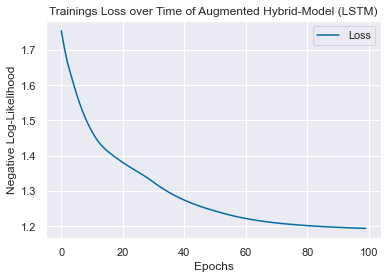

In [76]:
plot_loss(model_name = "Augmented Hybrid-Model (LSTM)",
          loss = loss_history_aug_lstm,
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [77]:
save_loss(loss_list = loss_history_aug_lstm,
          model_name = "aug_extended_lstm")

In [78]:
print("Trained Omega", garch_params_lstm.raw_omega.numpy())
print("Trained Alpha",garch_params_lstm.raw_alpha.numpy())
print("Trained Beta",garch_params_lstm.raw_beta.numpy())

Trained Omega [-2.3025851]
Trained Alpha -2.1972246
Trained Beta 1.3862944


In [79]:
# Re-Transform according to specified Model design
aug_lstm_raw_omega = garch_params_lstm.raw_omega.numpy()
aug_lstm_raw_alpha = garch_params_lstm.raw_alpha.numpy()
aug_lstm_raw_beta  = garch_params_lstm.raw_beta.numpy()

# Apply transformations manually
aug_lstm_omega = tf.nn.softplus(aug_lstm_raw_omega)                        # ω > 0
aug_lstm_alpha = tf.nn.sigmoid(aug_lstm_raw_alpha)                         # α ∈ (0,1)
aug_lstm_beta  = tf.nn.sigmoid(aug_lstm_raw_beta) * (1.0 - aug_lstm_alpha)          # β ∈ (0, 1 - α)

print(f"Re-Transformed ω = {aug_lstm_omega.numpy()[0]:.6f}")
print(f"Re-Transformed α = {aug_lstm_alpha.numpy():.6f}")
print(f"Re-Transformed β = {aug_lstm_beta.numpy():.6f}")
print(f"Re-Transformed α + β = {(aug_lstm_alpha + aug_lstm_beta).numpy():.6f}")


Re-Transformed ω = 0.095310
Re-Transformed α = 0.100000
Re-Transformed β = 0.720000
Re-Transformed α + β = 0.820000


In [80]:
aug_extended_lstm_parameters = pd.DataFrame(np.round([
                               [aug_lstm_omega.numpy()[0],
                                aug_lstm_alpha.numpy(),
                                aug_lstm_beta.numpy(),
                                aug_lstm_nn_adjust.numpy()]],4),
                                columns = ["Omega","Alpha","Beta","NN_Adjust"])
aug_extended_lstm_parameters

,Omega,Alpha,Beta,NN_Adjust
0,0.0953,0.1,0.72,0.3969


In [81]:
test_returns_tensor  = tf.convert_to_tensor(test_returns.values.flatten(), dtype=tf.float32) # test_returns.reset_index(drop = True)

preds_aug_extended_lstm, aug_lstm_nn_adjust_last_parms = compute_volatility_lstm(test_returns_tensor, 
                                                                        aug_extended_lstm, 
                                                                        garch_params_lstm)

In [82]:
n_step_qlikes_aug_ext_lstm,n_step_preds_aug_ext_lstm = build_lower_triangular_from_workflow_tf(net=aug_extended_lstm,
                                                                                                    model_name = "aug_ext_lstm",
                                                                                                    garch_params=garch_params_lstm,
                                                                                                    test_returns=test_returns,
                                                                                                    H=forecast_horizon
                                                                                                    )

Forecastin Horizon: 1
Forecastin Horizon: 2
Forecastin Horizon: 3
Forecastin Horizon: 4
Forecastin Horizon: 5
Forecastin Horizon: 6
Forecastin Horizon: 7
Forecastin Horizon: 8
Forecastin Horizon: 9
Forecastin Horizon: 10
Forecastin Horizon: 11
Forecastin Horizon: 12
Forecastin Horizon: 13
Forecastin Horizon: 14
Forecastin Horizon: 15
Forecastin Horizon: 16
Forecastin Horizon: 17
Forecastin Horizon: 18
Forecastin Horizon: 19
Forecastin Horizon: 20
Forecastin Horizon: 21
Forecastin Horizon: 22
Forecastin Horizon: 23
Forecastin Horizon: 24
Forecastin Horizon: 25
Forecastin Horizon: 26
Forecastin Horizon: 27
Forecastin Horizon: 28
Forecastin Horizon: 29
Forecastin Horizon: 30
Forecastin Horizon: 31
Forecastin Horizon: 32
Forecastin Horizon: 33
Forecastin Horizon: 34
Forecastin Horizon: 35
Forecastin Horizon: 36
Forecastin Horizon: 37
Forecastin Horizon: 38
Forecastin Horizon: 39
Forecastin Horizon: 40
Forecastin Horizon: 41
Forecastin Horizon: 42
Forecastin Horizon: 43
Forecastin Horizon: 

In [83]:
aug_lstm_qlikes_rsq,aug_lstm_qlikes_rv,aug_lstm_rmse_rsq,aug_lstm_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = n_step_preds_aug_ext_lstm,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [1.96 2.65 1.78 1.99]
RMSE Losses: 
 [ 9.74 11.59  2.73  4.01]


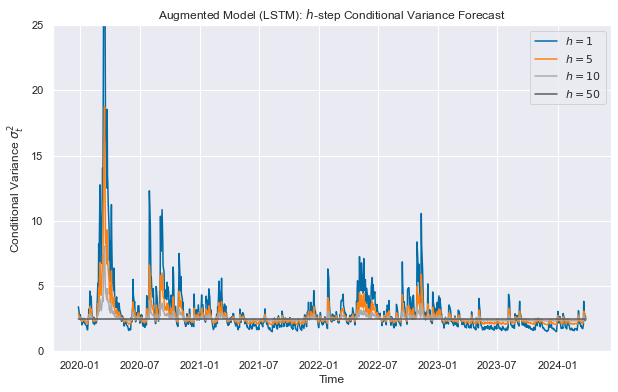

In [84]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("Augmented Model (LSTM): $h$-step Conditional Variance Forecast")
plt.plot(n_step_preds_aug_ext_lstm['h.001'], label = "$h=1$")
plt.plot(n_step_preds_aug_ext_lstm['h.005'], label = "$h=5$")
plt.plot(n_step_preds_aug_ext_lstm['h.010'], label = "$h=10$")
plt.plot(n_step_preds_aug_ext_lstm['h.050'], label = "$h=50$",alpha=1)
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.ylim(0,25)
plt.savefig(path + f"Plots/DataApp/Preds/aug_lstm_uncond_var.png")

# Augmented Model Comparison

# 2. Sequential Hybrid-Model

### 2.2 a) Sequential Hybrid-Model: Residual Approach (MLP)

In [85]:
garch_residual_model = arch_model(train_returns, mean='Zero', vol='GARCH', p=1, q=1).fit()
garch_preds_full_sample = garch_residual_model.forecast(horizon=forecast_horizon,
                          start=train_returns.index[0],   # first origin = last train date
                          reindex=True,
                          align="origin")

# Construct Test set based on GARCH-predictions 
garch_residual_model_test_returns = arch_model(test_returns, mean='Zero', vol='GARCH', p=1, q=1).fit()
garch_preds_residual_test_returns = garch_residual_model_test_returns.forecast(horizon=forecast_horizon, 
                              start=train_returns.index[0],   # first origin = last train date
                              reindex=True,
                              align="origin").variance["h.001"]


X_train_resid_mlp, y_train_resid_mlp, X_test_resid_mlp, y_test_resid_mlp, scaler_x_resid_mlp, scaler_y_resid_mlp = sequential_preprocess(train_returns = garch_preds_full_sample.variance["h.001"], 
                                           test_returns = train_sq_returns,
                                           reshape_dim = 2)

X_test_seq_residual_garch_preds_reshaped = np.array(garch_preds_residual_test_returns).reshape(-1, 1)  
X_test_seq_residual_scaled = scaler_x_resid_mlp.transform(X_test_seq_residual_garch_preds_reshaped)

model_mlp = Sequential([
Dense(16, activation='relu', input_shape=(1,)),
Dense(8, activation='relu'),
Dense(1, activation='softplus')  # guarantees positive output
])

optimizer = Adam(learning_rate=learning_rate) # Default is 0.001
model_mlp.compile(optimizer=optimizer, loss=gaussian_nll)#'mse')
loss_history_seq_resid_mlp = model_mlp.fit(X_train_resid_mlp, 
                                          y_train_resid_mlp, 
                                          epochs= epochs, 
                                          batch_size = batch_size, 
                                          validation_split = validation_split,
                                          verbose=0)

# Predict with MLP the scaled test-set of GARCH-predictions
y_pred_seq_resid_mlp_scaled = model_mlp.predict(X_test_seq_residual_scaled)
pred_seq_resid_mlp = scaler_y_resid_mlp.inverse_transform(y_pred_seq_resid_mlp_scaled).flatten()


seq_mlp_multi_step_qlikes,seq_mlp_multi_step_preds = nn_multi_step_preds(model_mlp,
                                         test_returns, 
                                         y_pred_seq_resid_mlp_scaled,#X_test_seq_residual_garch_preds_reshaped, 
                                         scaler_y = scaler_y_resid_mlp,
                                         scaler_x = None,
                                         H=forecast_horizon,
                                         model_name = "Sequential (MLP)")



X_train_resid_lstm, y_train_resid_lstm, X_test_resid_lstm, y_test_resid_lstm, scaler_x_resid_lstm, scaler_y_resid_lstm = sequential_preprocess(train_returns = np.array(garch_preds_full_sample.variance["h.001"]), 
                                           test_returns = test_returns,
                                           reshape_dim = 3)


model_lstm = Sequential([
LSTM(16, input_shape=(1, 1)),  # 1 time step, 1 feature
Dense(8, activation='relu'),
Dense(1, activation='softplus')  # ensures non-negative output
])

model_lstm.compile(optimizer=Adam(learning_rate= learning_rate), loss=gaussian_nll)
loss_history_seq_resid_lstm = model_lstm.fit(X_train_resid_lstm, 
                                               y_train_resid_lstm, 
                                               epochs= epochs, 
                                               batch_size=batch_size, 
                                               validation_split= validation_split,
                                               verbose=0)


# Reshape Test set based on GARCH-predictions for LSTM model
X_test_seq_residual_garch_preds_reshaped = np.array(garch_preds_residual_test_returns.dropna()).reshape(-1, 1)  
X_test_seq_residual_scaled = scaler_x_resid_lstm.transform(X_test_seq_residual_garch_preds_reshaped)

# Predict with LSTM the scaled test-set of GARCH-predictions and unscale 
y_pred_seq_resid_lstm_scaled = model_lstm.predict(X_test_seq_residual_scaled)
pred_seq_resid_lstm = scaler_y_resid_lstm.inverse_transform(y_pred_seq_resid_lstm_scaled).flatten()

seq_lstm_multi_step_qlikes,seq_lstm_multi_step_preds = nn_multi_step_preds(model_lstm,
                                         test_returns, 
                                         y_pred_seq_resid_lstm_scaled,#X_test_seq_residual_garch_preds_reshaped, 
                                         scaler_y_resid_lstm,
                                         H=forecast_horizon,
                                         model_name = "Sequential (LSTM)")

Iteration:      1,   Func. Count:      5,   Neg. LLF: 2447592156.0063114
Iteration:      2,   Func. Count:     12,   Neg. LLF: 11230.339043283751
Iteration:      3,   Func. Count:     18,   Neg. LLF: 8891.702386691668
Iteration:      4,   Func. Count:     23,   Neg. LLF: 10473.503715445127
Iteration:      5,   Func. Count:     28,   Neg. LLF: 8868.789891620789
Iteration:      6,   Func. Count:     33,   Neg. LLF: 8853.6679536389
Iteration:      7,   Func. Count:     37,   Neg. LLF: 8853.463972382026
Iteration:      8,   Func. Count:     41,   Neg. LLF: 8853.44933177701
Iteration:      9,   Func. Count:     45,   Neg. LLF: 8853.428978751537
Iteration:     10,   Func. Count:     49,   Neg. LLF: 8853.425778367255
Iteration:     11,   Func. Count:     53,   Neg. LLF: 8853.422898449026
Iteration:     12,   Func. Count:     57,   Neg. LLF: 8853.422765761896
Iteration:     13,   Func. Count:     61,   Neg. LLF: 8853.422760499503
Iteration:     14,   Func. Count:     64,   Neg. LLF: 8853.42276

/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Forecast Horizon: 1
Forecast Horizon: 2
Forecast Horizon: 3
Forecast Horizon: 4
Forecast Horizon: 5
Forecast Horizon: 6
Forecast Horizon: 7
Forecast Horizon: 8
Forecast Horizon: 9
Forecast Horizon: 10
Forecast Horizon: 11
Forecast Horizon: 12
Forecast Horizon: 13
Forecast Horizon: 14
Forecast Horizon: 15
Forecast Horizon: 16
Forecast Horizon: 17
Forecast Horizon: 18
Forecast Horizon: 19
Forecast Horizon: 20
Forecast Horizon: 21
Forecast Horizon: 22
Forecast Horizon: 23
Forecast Horizon: 24
Forecast Horizon: 25
Forecast Horizon: 26
Forecast Horizon: 27
Forecast Horizon: 28
Forecast Horizon: 29
Forecast Horizon: 30
Forecast Horizon: 31
Forecast Horizon: 32
Forecast Horizon: 33
Forecast Horizon: 34
Forecast Horizon: 35
Forecast Horizon: 36
Forecast Horizon: 37
Forecast Horizon: 38
Forecast Horizon: 39
Forecast Horizon: 40
Forecast Horizon: 41
Forecast Horizon: 42
Forecast Horizon: 43
Forecast Horizon: 44
Forecast Horizon: 45
Forecast Horizon: 46
For

/Users/akirasohejl/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Forecast Horizon: 1
Forecast Horizon: 2
Forecast Horizon: 3
Forecast Horizon: 4
Forecast Horizon: 5
Forecast Horizon: 6
Forecast Horizon: 7
Forecast Horizon: 8
Forecast Horizon: 9
Forecast Horizon: 10
Forecast Horizon: 11
Forecast Horizon: 12
Forecast Horizon: 13
Forecast Horizon: 14
Forecast Horizon: 15
Forecast Horizon: 16
Forecast Horizon: 17
Forecast Horizon: 18
Forecast Horizon: 19
Forecast Horizon: 20
Forecast Horizon: 21
Forecast Horizon: 22
Forecast Horizon: 23
Forecast Horizon: 24
Forecast Horizon: 25
Forecast Horizon: 26
Forecast Horizon: 27
Forecast Horizon: 28
Forecast Horizon: 29
Forecast Horizon: 30
Forecast Horizon: 31
Forecast Horizon: 32
Forecast Horizon: 33
Forecast Horizon: 34
Forecast Horizon: 35
Forecast Horizon: 36
Forecast Horizon: 37
Forecast Horizon: 38
Forecast Horizon: 39
Forecast Horizon: 40
Forecast Horizon: 41
Forecast Horizon: 42
Forecast Horizon: 43
Forecast Horizon: 44
Forecast Horizon: 45
Forecast Horizon: 46
Fore

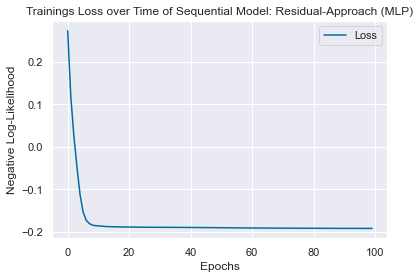

In [86]:
plot_loss(model_name = "Sequential Model: Residual-Approach (MLP)",
          loss = loss_history_seq_resid_mlp.history['loss'],
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [87]:
save_loss(loss_list = loss_history_seq_resid_mlp.history['loss'],
          model_name = "seq_resid_mlp")

In [88]:
seq_mlp_qlikes_rsq,seq_mlp_qlikes_rv,seq_mlp_rmse_rsq,seq_mlp_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = seq_mlp_multi_step_preds,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon, decimal = 2)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [2.34 2.3  2.16 2.11]
RMSE Losses: 
 [10.4  10.64  5.83  6.38]


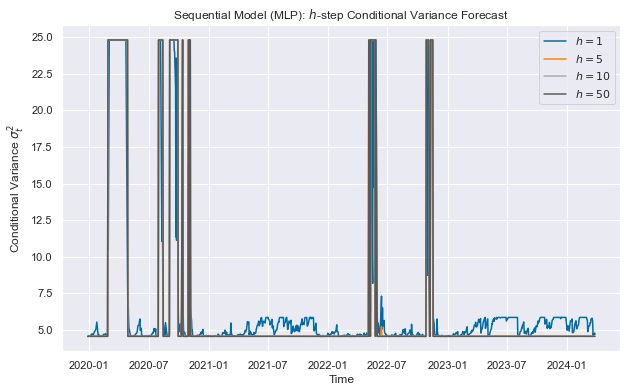

In [89]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("Sequential Model (MLP): $h$-step Conditional Variance Forecast")
plt.plot(seq_mlp_multi_step_preds['h.001'], label = "$h=1$")
plt.plot(seq_mlp_multi_step_preds['h.005'], label = "$h=5$")
plt.plot(seq_mlp_multi_step_preds['h.010'], label = "$h=10$")
plt.plot(seq_mlp_multi_step_preds['h.050'], label = "$h=50$",alpha=1)
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/seq_mlp_uncond_var.png")

In [90]:
save_loss(loss_list = loss_history_seq_resid_lstm.history['loss'],
          model_name = "seq_resid_lstm")

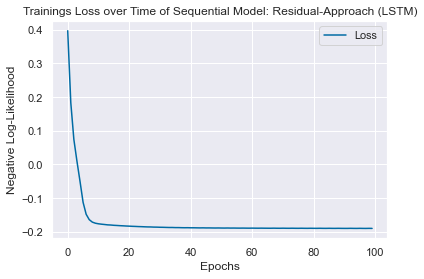

In [91]:
plot_loss(model_name = "Sequential Model: Residual-Approach (LSTM)",
          loss = loss_history_seq_resid_lstm.history['loss'],
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [92]:
seq_lstm_qlikes_rsq,seq_lstm_qlikes_rv,seq_lstm_rmse_rsq,seq_lstm_rmse_rv = comp_nstep_qlike_rmse(preds_matrix = seq_lstm_multi_step_preds,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon,decimal = 2)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [2.34 2.29 2.16 2.11]
RMSE Losses: 
 [10.41 10.58  5.88  6.29]


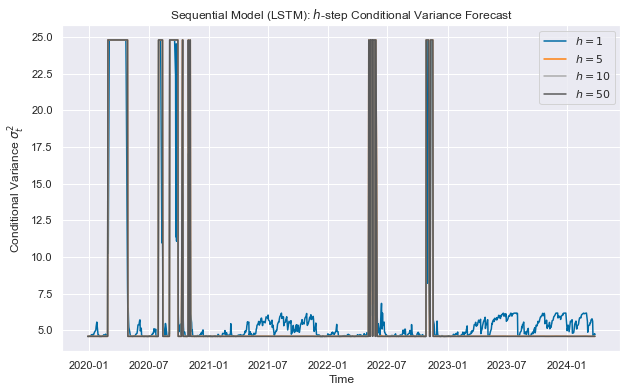

In [93]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("Sequential Model (LSTM): $h$-step Conditional Variance Forecast")
plt.plot(seq_lstm_multi_step_preds['h.001'], label = "$h=1$")
plt.plot(seq_lstm_multi_step_preds['h.005'], label = "$h=5$")
plt.plot(seq_lstm_multi_step_preds['h.010'], label = "$h=10$")
plt.plot(seq_lstm_multi_step_preds['h.050'], label = "$h=50$",alpha=1)
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/seq_lstm_uncond_var.png")

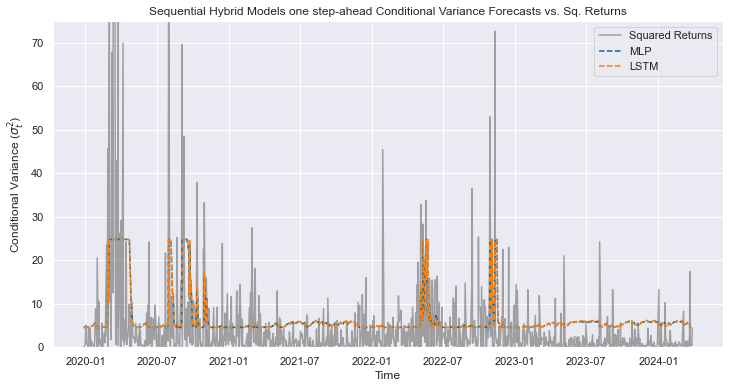

In [94]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_index,test_returns**2, label = "Squared Returns", color = 'grey', alpha = 0.7)
plt.plot(seq_mlp_multi_step_preds["h.001"], label = "MLP", linestyle = "dashed")
plt.plot(seq_lstm_multi_step_preds["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Sequential Hybrid Models one step-ahead Conditional Variance Forecasts vs. Sq. Returns")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.ylim(0,75)
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/seq_onestep_compared_preds.png')

# 3. Integrated Hybrid-Model

In [95]:
%run "03_integrated_architecture.ipynb"

In [96]:
returns_tensor = torch.tensor(returns.values, dtype=torch.float32)

## 3.1 Integrated-MLP Hybrid-Model

In [97]:
start = time.time()
Integrated_MLP_preds, test_returns_rescaled, integrated_mlp_model, x_values, loss_history_int_mlp = train_integrated_MLP(returns_tensor, 
                                                                                                   train_ratio=0.8, 
                                                                                                   num_epochs=epochs,
                                                                                                   lr=learning_rate, 
                                                                                                   warmup_window=20)
end = time.time()
print("Computation time for Integrated Hybrid-Model MLP estimation:",end - start, "seconds")

Epoch 0, Train NLL: 0.932077
Epoch 1, Train NLL: 0.928747
Epoch 2, Train NLL: 0.925446
Epoch 3, Train NLL: 0.922172
Epoch 4, Train NLL: 0.918926
Epoch 5, Train NLL: 0.915708
Epoch 6, Train NLL: 0.912519
Epoch 7, Train NLL: 0.909358
Epoch 8, Train NLL: 0.906226
Epoch 9, Train NLL: 0.903123
Epoch 10, Train NLL: 0.900048
Epoch 11, Train NLL: 0.897002
Epoch 12, Train NLL: 0.893985
Epoch 13, Train NLL: 0.890997
Epoch 14, Train NLL: 0.888038
Epoch 15, Train NLL: 0.885108
Epoch 16, Train NLL: 0.882207
Epoch 17, Train NLL: 0.879335
Epoch 18, Train NLL: 0.876492
Epoch 19, Train NLL: 0.873677
Epoch 20, Train NLL: 0.870891
Epoch 21, Train NLL: 0.868134
Epoch 22, Train NLL: 0.865405
Epoch 23, Train NLL: 0.862705
Epoch 24, Train NLL: 0.860032
Epoch 25, Train NLL: 0.857388
Epoch 26, Train NLL: 0.854772
Epoch 27, Train NLL: 0.852183
Epoch 28, Train NLL: 0.849621
Epoch 29, Train NLL: 0.847087
Epoch 30, Train NLL: 0.844580
Epoch 31, Train NLL: 0.842100
Epoch 32, Train NLL: 0.839647
Epoch 33, Train NLL:

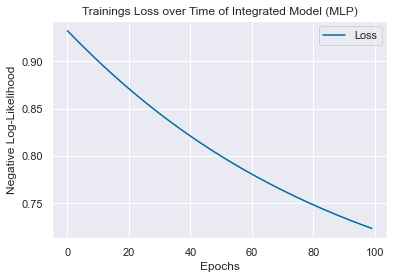

In [219]:
plot_loss(model_name = "Integrated Model (MLP)",
          loss = loss_history_int_mlp,
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [99]:
def read_loss(model, path = "/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Loss/"):    
    loss = pd.read_csv(path + f"{model}_loss_history.csv", header = None)
    return(loss)

In [100]:
dict_losses = {}
for m in ["nn_mlp","nn_lstm"]:
    dict_losses[m] = read_loss(model = m)[0]

In [101]:
save_loss(loss_list = loss_history_int_mlp,
          model_name = "integ_mlp")

In [233]:
print("Estimated Omega:",torch.nn.functional.softplus(integrated_mlp_model.omega_raw.detach()).numpy()[0])
print("Estimated Alpha:",integrated_mlp_model.alpha.detach().numpy()[0])
print("Estimated Beta:",integrated_mlp_model.beta.detach().numpy()[0])

Estimated Omega: 0.66803545
Estimated Alpha: 0.007904387
Estimated Beta: 0.76424766


In [234]:
int_mlp_parameters = pd.DataFrame([np.round([torch.nn.functional.softplus(integrated_mlp_model.omega_raw.detach()).numpy()[0],
                                    integrated_mlp_model.alpha.detach().numpy()[0],
                                    integrated_mlp_model.beta.detach().numpy()[0]],4)],
                                    columns = ["Omega","Alpha","Beta"])
int_mlp_parameters

,Omega,Alpha,Beta
0,0.668,0.0079,0.7642


In [104]:
int_mlp_n_step_qlikes,int_mlp_n_step_preds = multi_step_preds_torch(model = integrated_mlp_model,
                                                      model_name = "int_mlp",
                                                       test_returns = test_returns,
                                                       H = forecast_horizon)

Forecast Horizon: 1
Forecast Horizon: 2
Forecast Horizon: 3
Forecast Horizon: 4
Forecast Horizon: 5
Forecast Horizon: 6
Forecast Horizon: 7
Forecast Horizon: 8
Forecast Horizon: 9
Forecast Horizon: 10
Forecast Horizon: 11
Forecast Horizon: 12
Forecast Horizon: 13
Forecast Horizon: 14
Forecast Horizon: 15
Forecast Horizon: 16
Forecast Horizon: 17
Forecast Horizon: 18
Forecast Horizon: 19
Forecast Horizon: 20
Forecast Horizon: 21
Forecast Horizon: 22
Forecast Horizon: 23
Forecast Horizon: 24
Forecast Horizon: 25
Forecast Horizon: 26
Forecast Horizon: 27
Forecast Horizon: 28
Forecast Horizon: 29
Forecast Horizon: 30
Forecast Horizon: 31
Forecast Horizon: 32
Forecast Horizon: 33
Forecast Horizon: 34
Forecast Horizon: 35
Forecast Horizon: 36
Forecast Horizon: 37
Forecast Horizon: 38
Forecast Horizon: 39
Forecast Horizon: 40
Forecast Horizon: 41
Forecast Horizon: 42
Forecast Horizon: 43
Forecast Horizon: 44
Forecast Horizon: 45
Forecast Horizon: 46
Forecast Horizon: 47
Forecast Horizon: 48
F

In [105]:
int_mlp_n_step_preds,origins = lower_triangular_forecasts(integrated_mlp_model,
                               returns_tensor = returns_tensor,
                               train_ratio = 0.8,
                               H = forecast_horizon)
    
    
int_mlp_n_step_preds = pd.DataFrame(int_mlp_n_step_preds, index= test_returns.index)

int_mlp_multi_step_qlikes = []
for i in range(0,forecast_horizon):
    int_mlp_multi_step_qlikes.append(forecast_metrics(preds = int_mlp_n_step_preds.iloc[:,i],
                       y_test = test_sq_returns, 
                       model = "seq_mlp",
                       round_decimal = 4,
                       qlike_only = True))

In [106]:
int_mlp_qlikes_rsq,int_mlp_qlikes_rv,int_mlp_rmse_rsq,int_mlp_rmse_rv =comp_nstep_qlike_rmse(preds_matrix = int_mlp_n_step_preds,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [2.91 2.93 2.79 2.81]
RMSE Losses: 
 [14.47 14.74 11.34 11.64]


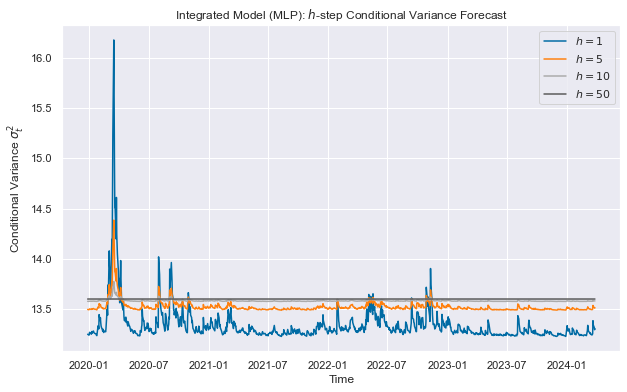

In [107]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("Integrated Model (MLP): $h$-step Conditional Variance Forecast")
plt.plot(int_mlp_n_step_preds[0], label = "$h=1$")
plt.plot(int_mlp_n_step_preds[4], label = "$h=5$")
plt.plot(int_mlp_n_step_preds[9], label = "$h=10$")
plt.plot(int_mlp_n_step_preds[49], label = "$h=50$",alpha=1)
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/int_mlp_uncond_var.png")

## 3.2 Integrated-LSTM Hybrid-Model

In [108]:
returns_tensor = torch.tensor(returns.values, dtype=torch.float32)

In [109]:
# Prepare training data
sigma_sq_init = torch.tensor((train_returns[:2]**2).mean()).unsqueeze(0).unsqueeze(1).to(torch.float32)
sq_returns_tm1_all = torch.tensor(train_returns[:-1]**2).unsqueeze(1)
returns_t = torch.tensor(train_returns)[1:].unsqueeze(1)
c_init = torch.zeros(1, 16)

In [110]:
# Initialize Integrated LSTM Model
integrated_lstm_model = IntegratedLSTM()
optimizer = torch.optim.Adam(integrated_lstm_model.parameters(), lr=0.01)

start = time.time()
# Train
loss_history_int_lstm = []
for epoch in range(100):
    sigma_sq_tm1 = sigma_sq_init.clone()
    c_t = c_init.clone()
    total_loss = 0.0
    #print(epoch)
    for t in range(len(sq_returns_tm1_all)):
        eps_sq_tm1 = sq_returns_tm1_all[t].unsqueeze(0)
        ret_t = returns_t[t].unsqueeze(0)
        sigma_sq_t, c_t = integrated_lstm_model(eps_sq_tm1.to(torch.float32), sigma_sq_tm1, c_t)
        nll = 0.5 * (torch.log(sigma_sq_t) + ret_t**2 / sigma_sq_t)
        total_loss += nll.mean()
        sigma_sq_tm1 = sigma_sq_t.detach()
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    loss_history_int_lstm.append(total_loss.item())
    print("Epoch:" ,epoch + 1, "| Loss:" ,total_loss.item())
    
end
print("Computation time for Integrated Hybrid-Model LSTM estimation:",end - start, "seconds")

Epoch: 1 | Loss: 5476.068213466575
Epoch: 2 | Loss: 5343.556183782858
Epoch: 3 | Loss: 5239.794627982066
Epoch: 4 | Loss: 5163.53614256453
Epoch: 5 | Loss: 5113.03346094915
Epoch: 6 | Loss: 5087.517266809617
Epoch: 7 | Loss: 5082.696287898932
Epoch: 8 | Loss: 5087.142668900793
Epoch: 9 | Loss: 5089.147821050091
Epoch: 10 | Loss: 5085.153811436307
Epoch: 11 | Loss: 5076.493266775397
Epoch: 12 | Loss: 5065.505217665736
Epoch: 13 | Loss: 5054.185555403307
Epoch: 14 | Loss: 5043.859234468594
Epoch: 15 | Loss: 5035.219208486072
Epoch: 16 | Loss: 5028.481309874897
Epoch: 17 | Loss: 5023.513175516193
Epoch: 18 | Loss: 5019.981995898572
Epoch: 19 | Loss: 5017.478769392594
Epoch: 20 | Loss: 5015.611171228876
Epoch: 21 | Loss: 5014.061784354896
Epoch: 22 | Loss: 5012.614427767969
Epoch: 23 | Loss: 5011.157537403664
Epoch: 24 | Loss: 5009.668891574175
Epoch: 25 | Loss: 5008.189206282217
Epoch: 26 | Loss: 5006.792968628913
Epoch: 27 | Loss: 5005.561869447065
Epoch: 28 | Loss: 5004.5622707797265
Ep

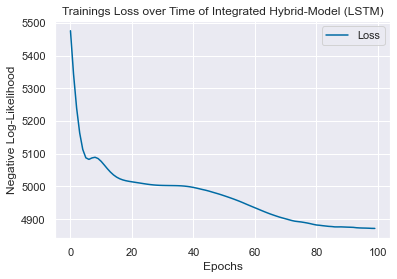

In [220]:
plot_loss(model_name = "Integrated Hybrid-Model (LSTM)",
          loss = loss_history_int_lstm,
          loss_name = "Negative Log-Likelihood",
          sim = False,
         path = path + "Plots/DataApp/Loss")

In [112]:
save_loss(loss_list = loss_history_int_lstm,
          model_name = "integ_lstm")

In [113]:
# Forecast
sigma_sq_tm1 = torch.tensor(train_returns.iloc[-1]**2).unsqueeze(0).unsqueeze(1).to(torch.float32)
c_t = c_init.clone()
integrated_lstm_preds = []
for t in range(len(test_returns)):
    eps_sq_tm1 = torch.tensor(test_returns.iloc[t]**2).unsqueeze(0).unsqueeze(1).to(torch.float32)
    sigma_sq_t, c_t = integrated_lstm_model(eps_sq_tm1, sigma_sq_tm1, c_t)
    integrated_lstm_preds.append(sigma_sq_t.detach())
    sigma_sq_tm1 = sigma_sq_t.detach()
    
integrated_lstm_preds_tensor = torch.cat(integrated_lstm_preds).squeeze()

In [221]:
print("Estimated Omega:",integrated_lstm_model.omega_raw.detach().numpy()[0])
print("Estimated Alpha:",integrated_lstm_model.alpha.detach().numpy()[0])
print("Estimated Beta:",integrated_lstm_model.beta.detach().numpy()[0])

Estimated Omega: -0.28404164
Estimated Alpha: 0.073498845
Estimated Beta: 0.80713415


In [235]:
int_lstm_parameters = pd.DataFrame([np.round([torch.nn.functional.softplus(integrated_lstm_model.omega_raw.detach()).numpy()[0],
                                    integrated_lstm_model.alpha.detach().numpy()[0],
                                    integrated_lstm_model.beta.detach().numpy()[0]],4)],
                                    columns = ["Omega","Alpha","Beta"])
int_lstm_parameters

,Omega,Alpha,Beta
0,0.5612,0.0735,0.8071


In [116]:
%run 03_integrated_architecture.ipynb

In [117]:
_, n_step_int_lstm_preds = lower_triangular_from_test_lstm(
                                                        integrated_lstm_model,
                                                        model_name = "int_lstm",
                                                        test_sq_returns=torch.tensor(test_sq_returns.values, 
                                                                                     dtype=torch.float32), 
                                                        sigma_sq_init=sigma_sq_tm1,                      # carry-over from train
                                                        c_init=c_init,
                                                        )

Forecast Origin: 0 
####################################
Forecast Origin: 1 
####################################
Forecast Origin: 2 
####################################
Forecast Origin: 3 
####################################
Forecast Origin: 4 
####################################
Forecast Origin: 5 
####################################
Forecast Origin: 6 
####################################
Forecast Origin: 7 
####################################
Forecast Origin: 8 
####################################
Forecast Origin: 9 
####################################
Forecast Origin: 10 
####################################
Forecast Origin: 11 
####################################
Forecast Origin: 12 
####################################
Forecast Origin: 13 
####################################
Forecast Origin: 14 
####################################
Forecast Origin: 15 
####################################
Forecast Origin: 16 
####################################
Forecast Origin: 17 
###

Forecast Origin: 141 
####################################
Forecast Origin: 142 
####################################
Forecast Origin: 143 
####################################
Forecast Origin: 144 
####################################
Forecast Origin: 145 
####################################
Forecast Origin: 146 
####################################
Forecast Origin: 147 
####################################
Forecast Origin: 148 
####################################
Forecast Origin: 149 
####################################
Forecast Origin: 150 
####################################
Forecast Origin: 151 
####################################
Forecast Origin: 152 
####################################
Forecast Origin: 153 
####################################
Forecast Origin: 154 
####################################
Forecast Origin: 155 
####################################
Forecast Origin: 156 
####################################
Forecast Origin: 157 
##################################

Forecast Origin: 281 
####################################
Forecast Origin: 282 
####################################
Forecast Origin: 283 
####################################
Forecast Origin: 284 
####################################
Forecast Origin: 285 
####################################
Forecast Origin: 286 
####################################
Forecast Origin: 287 
####################################
Forecast Origin: 288 
####################################
Forecast Origin: 289 
####################################
Forecast Origin: 290 
####################################
Forecast Origin: 291 
####################################
Forecast Origin: 292 
####################################
Forecast Origin: 293 
####################################
Forecast Origin: 294 
####################################
Forecast Origin: 295 
####################################
Forecast Origin: 296 
####################################
Forecast Origin: 297 
##################################

Forecast Origin: 421 
####################################
Forecast Origin: 422 
####################################
Forecast Origin: 423 
####################################
Forecast Origin: 424 
####################################
Forecast Origin: 425 
####################################
Forecast Origin: 426 
####################################
Forecast Origin: 427 
####################################
Forecast Origin: 428 
####################################
Forecast Origin: 429 
####################################
Forecast Origin: 430 
####################################
Forecast Origin: 431 
####################################
Forecast Origin: 432 
####################################
Forecast Origin: 433 
####################################
Forecast Origin: 434 
####################################
Forecast Origin: 435 
####################################
Forecast Origin: 436 
####################################
Forecast Origin: 437 
##################################

Forecast Origin: 561 
####################################
Forecast Origin: 562 
####################################
Forecast Origin: 563 
####################################
Forecast Origin: 564 
####################################
Forecast Origin: 565 
####################################
Forecast Origin: 566 
####################################
Forecast Origin: 567 
####################################
Forecast Origin: 568 
####################################
Forecast Origin: 569 
####################################
Forecast Origin: 570 
####################################
Forecast Origin: 571 
####################################
Forecast Origin: 572 
####################################
Forecast Origin: 573 
####################################
Forecast Origin: 574 
####################################
Forecast Origin: 575 
####################################
Forecast Origin: 576 
####################################
Forecast Origin: 577 
##################################

Forecast Origin: 701 
####################################
Forecast Origin: 702 
####################################
Forecast Origin: 703 
####################################
Forecast Origin: 704 
####################################
Forecast Origin: 705 
####################################
Forecast Origin: 706 
####################################
Forecast Origin: 707 
####################################
Forecast Origin: 708 
####################################
Forecast Origin: 709 
####################################
Forecast Origin: 710 
####################################
Forecast Origin: 711 
####################################
Forecast Origin: 712 
####################################
Forecast Origin: 713 
####################################
Forecast Origin: 714 
####################################
Forecast Origin: 715 
####################################
Forecast Origin: 716 
####################################
Forecast Origin: 717 
##################################

Forecast Origin: 841 
####################################
Forecast Origin: 842 
####################################
Forecast Origin: 843 
####################################
Forecast Origin: 844 
####################################
Forecast Origin: 845 
####################################
Forecast Origin: 846 
####################################
Forecast Origin: 847 
####################################
Forecast Origin: 848 
####################################
Forecast Origin: 849 
####################################
Forecast Origin: 850 
####################################
Forecast Origin: 851 
####################################
Forecast Origin: 852 
####################################
Forecast Origin: 853 
####################################
Forecast Origin: 854 
####################################
Forecast Origin: 855 
####################################
Forecast Origin: 856 
####################################
Forecast Origin: 857 
##################################

Forecast Origin: 981 
####################################
Forecast Origin: 982 
####################################
Forecast Origin: 983 
####################################
Forecast Origin: 984 
####################################
Forecast Origin: 985 
####################################
Forecast Origin: 986 
####################################
Forecast Origin: 987 
####################################
Forecast Origin: 988 
####################################
Forecast Origin: 989 
####################################
Forecast Origin: 990 
####################################
Forecast Origin: 991 
####################################
Forecast Origin: 992 
####################################
Forecast Origin: 993 
####################################
Forecast Origin: 994 
####################################
Forecast Origin: 995 
####################################
Forecast Origin: 996 
####################################
Forecast Origin: 997 
##################################

In [118]:
n_step_int_lstm_preds.index = test_sq_returns.index#[:100]

In [301]:
int_lstm_qlikes_rsq,int_lstm_qlikes_rv,int_lstm_rmse_rsq,int_lstm_rmse_rv =comp_nstep_qlike_rmse(preds_matrix = n_step_int_lstm_preds,
                      test_proxy1 = test_sq_returns,
                      test_proxy2 = test_rv,
                      H = forecast_horizon, decimal = 2)

(Sq.R. h = 1), (Sq.R. h = 100), (RV h = 1), (RV, h = 100) 

QLIKE Losses: 
 [2.08 2.85 1.89 2.7 ]
RMSE Losses: 
 [ 9.96 14.59  3.39 11.13]


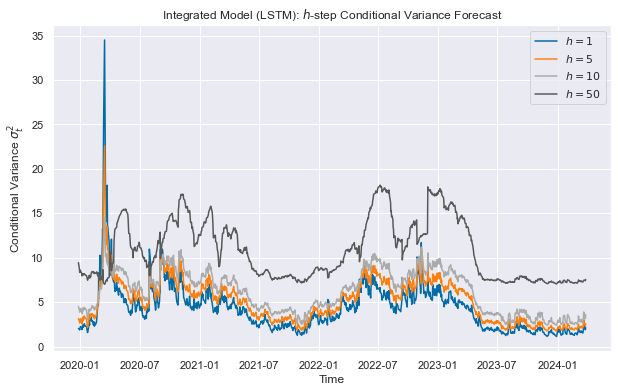

In [120]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(10,6))
plt.title("Integrated Model (LSTM): $h$-step Conditional Variance Forecast")
plt.plot(n_step_int_lstm_preds["h.001"], label = "$h=1$")
plt.plot(n_step_int_lstm_preds["h.005"], label = "$h=5$")
plt.plot(n_step_int_lstm_preds["h.010"], label = "$h=10$")
plt.plot(n_step_int_lstm_preds["h.050"], label = "$h=50$",alpha=1)
#plt.plot(test_index,np.repeat(uncond_var_egarch,len(test_returns)),linestyle = "dashed", color = "grey")
plt.xlabel("Time")
plt.ylabel("Conditional Variance $\sigma^2_t$")
plt.legend()
plt.savefig(path + f"Plots/DataApp/Preds/int_lstm_uncond_var.png")

# All Forecasts compared

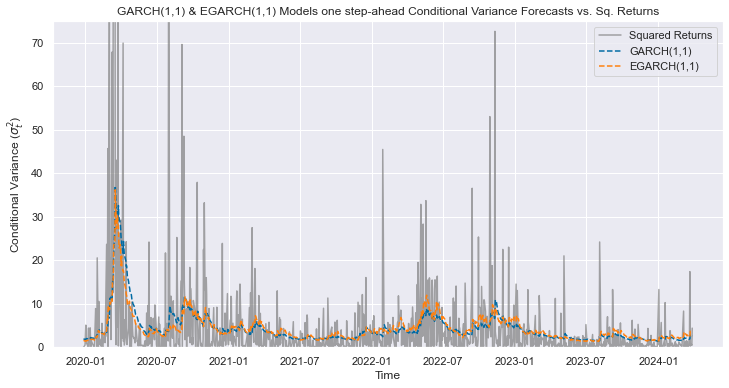

In [121]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_sq_returns, label = "Squared Returns", color = 'grey', alpha = 0.7)
plt.plot(garch_one_step_preds, label = "GARCH(1,1)", linestyle = "dashed")
plt.plot(egarch_one_step_preds, label = "EGARCH(1,1)", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"GARCH(1,1) & EGARCH(1,1) Models one step-ahead Conditional Variance Forecasts vs. Sq. Returns")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.ylim(0,75)
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/Econ_onestep_compared_preds_rsq.png')

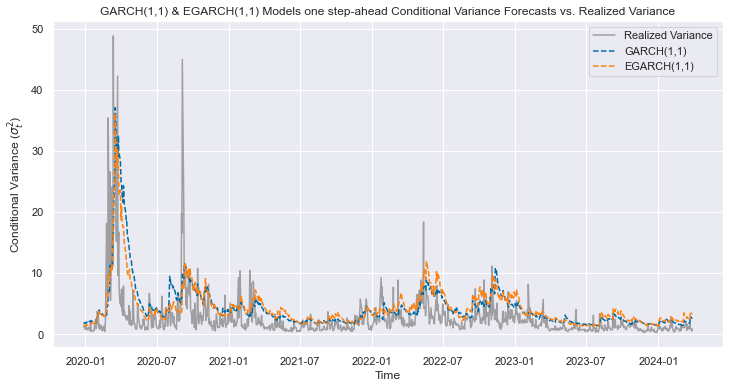

In [122]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_index,test_rv, label = "Realized Variance", color = 'grey', alpha = 0.7)
plt.plot(garch_one_step_preds, label = "GARCH(1,1)", linestyle = "dashed")
plt.plot(egarch_one_step_preds, label = "EGARCH(1,1)", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"GARCH(1,1) & EGARCH(1,1) Models one step-ahead Conditional Variance Forecasts vs. Realized Variance")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/Econ_onestep_compared_preds_rv.png')

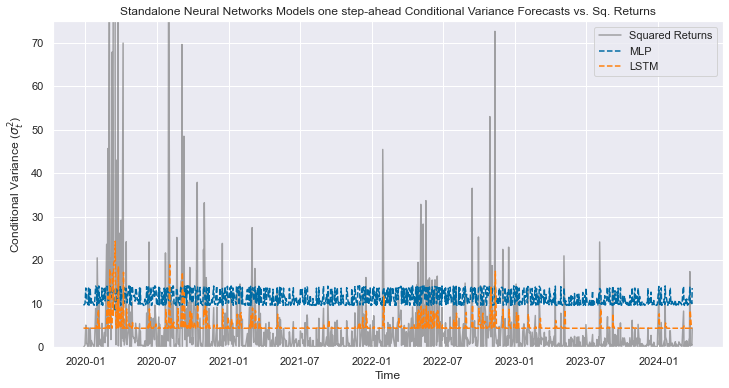

In [123]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_sq_returns, label = "Squared Returns", color = 'grey', alpha = 0.7)
plt.plot(n_step_preds_mlp["h.001"], label = "MLP", linestyle = "dashed")
plt.plot(lstm_n_step_preds["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Standalone Neural Networks Models one step-ahead Conditional Variance Forecasts vs. Sq. Returns")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.ylim(0,75)
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/nn_onestep_compared_preds_sqr.png')

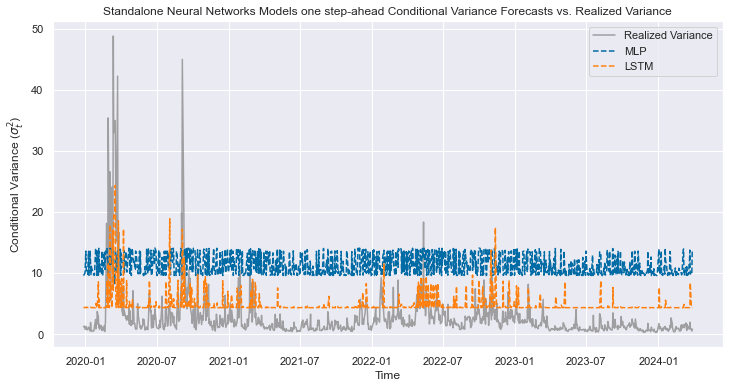

In [124]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_rv, label = "Realized Variance", color = 'grey', alpha = 0.7)
plt.plot(n_step_preds_mlp["h.001"], label = "MLP", linestyle = "dashed")
plt.plot(lstm_n_step_preds["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Standalone Neural Networks Models one step-ahead Conditional Variance Forecasts vs. Realized Variance")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/nn_onestep_compared_preds_rv.png')

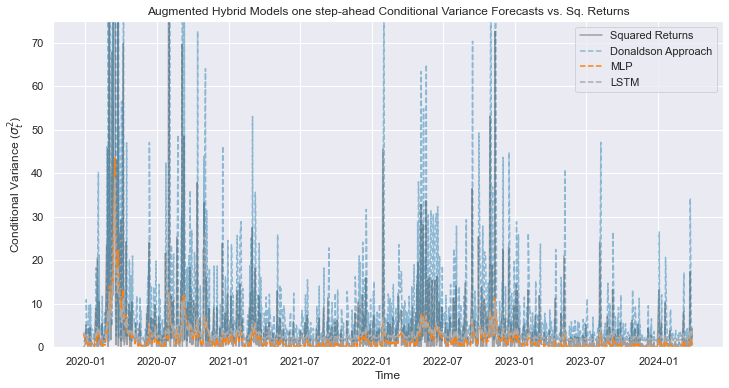

In [137]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_sq_returns, label = "Squared Returns", color = 'grey', alpha = 0.7)
plt.plot(n_step_preds_aug_donald["h.001"], label = "Donaldson Approach", linestyle = "dashed", alpha = 0.4)
plt.plot(n_step_preds_aug_ext_mlp["h.001"], label = "MLP", linestyle = "dashed")
plt.plot(n_step_preds_aug_ext_lstm["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Augmented Hybrid Models one step-ahead Conditional Variance Forecasts vs. Sq. Returns")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.ylim(0,75)
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/aug_onestep_compared_preds_sqr.png')

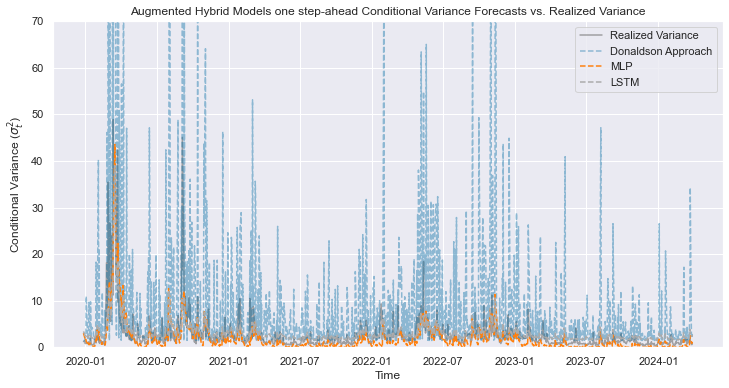

In [126]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_index,test_rv, label = "Realized Variance", color = 'grey', alpha = 0.7)
plt.plot(n_step_preds_aug_donald["h.001"], label = "Donaldson Approach", linestyle = "dashed", alpha = 0.4)
plt.plot(n_step_preds_aug_ext_mlp["h.001"], label = "MLP", linestyle = "dashed")
plt.plot(n_step_preds_aug_ext_lstm["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Augmented Hybrid Models one step-ahead Conditional Variance Forecasts vs. Realized Variance")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.ylim(0,70)
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/aug_onestep_compared_preds_rv.png')

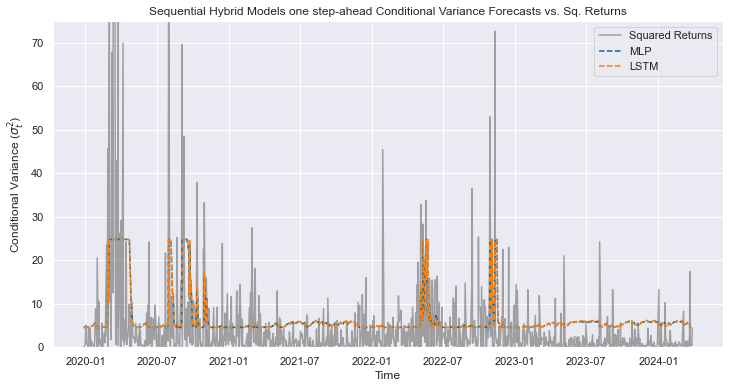

In [127]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_sq_returns, label = "Squared Returns", color = 'grey', alpha = 0.7)
plt.plot(seq_mlp_multi_step_preds["h.001"], label = "MLP", linestyle = "dashed")
plt.plot(seq_lstm_multi_step_preds["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Sequential Hybrid Models one step-ahead Conditional Variance Forecasts vs. Sq. Returns")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.ylim(0,75)
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/seq_onestep_compared_preds_sqr.png')

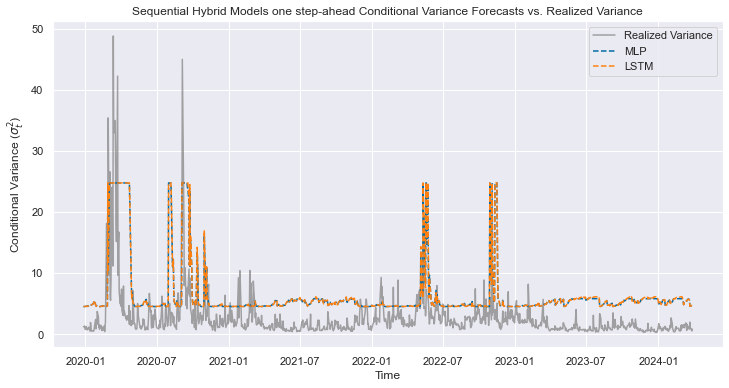

In [128]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_rv, label = "Realized Variance", color = 'grey', alpha = 0.7)
plt.plot(seq_mlp_multi_step_preds["h.001"], label = "MLP", linestyle = "dashed")
plt.plot(seq_lstm_multi_step_preds["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Sequential Hybrid Models one step-ahead Conditional Variance Forecasts vs. Realized Variance")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/seq_onestep_compared_preds_rv.png')

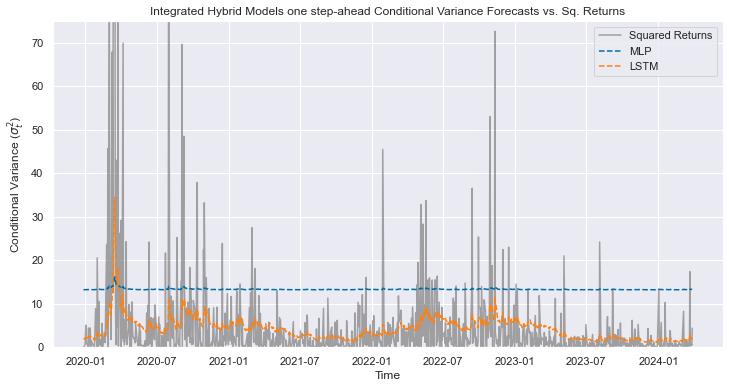

In [129]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_sq_returns, label = "Squared Returns", color = 'grey', alpha = 0.7)
plt.plot(int_mlp_n_step_preds[0], label = "MLP", linestyle = "dashed")
plt.plot(n_step_int_lstm_preds["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Integrated Hybrid Models one step-ahead Conditional Variance Forecasts vs. Sq. Returns")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.ylim(0,75)
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/int_onestep_compared_preds_sqr.png')

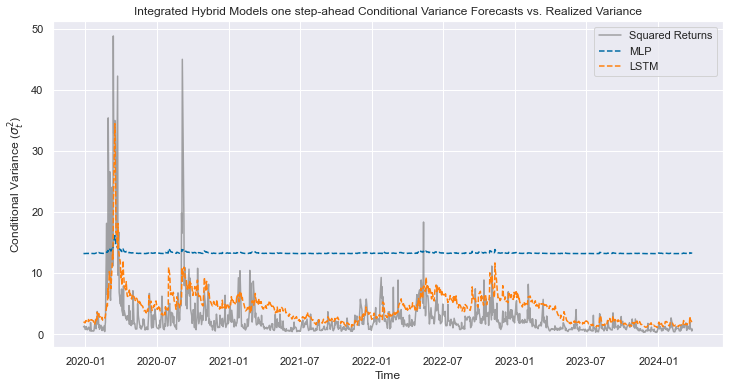

In [130]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.plot(test_rv, label = "Squared Returns", color = 'grey', alpha = 0.7)
plt.plot(int_mlp_n_step_preds[0], label = "MLP", linestyle = "dashed")
plt.plot(n_step_int_lstm_preds["h.001"], label = "LSTM", linestyle = "dashed")
plt.xlabel("Time")
plt.ylabel(f"Conditional Variance ($\sigma_t^2$)")
plt.title(f"Integrated Hybrid Models one step-ahead Conditional Variance Forecasts vs. Realized Variance")
#plt.ylabel(f"Log Variance ($\log \sigma_t^2$)")
#plt.title(f"Econometric Models (GARCH & EGARCH) one step-ahead Conditional Variance Forecasts vs. Sq. Returns ($\gamma$ = {gamma})")
plt.legend()
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/Preds/int_onestep_compared_preds_rv.png')

# Multi-Step Predictions

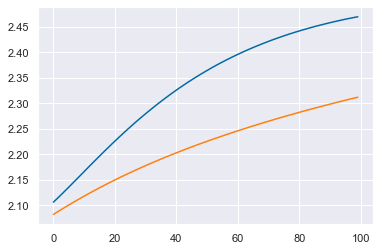

In [131]:
plt.plot(egarch_origin_qlikes_rsq)
plt.plot(garch_origin_qlikes_rsq)

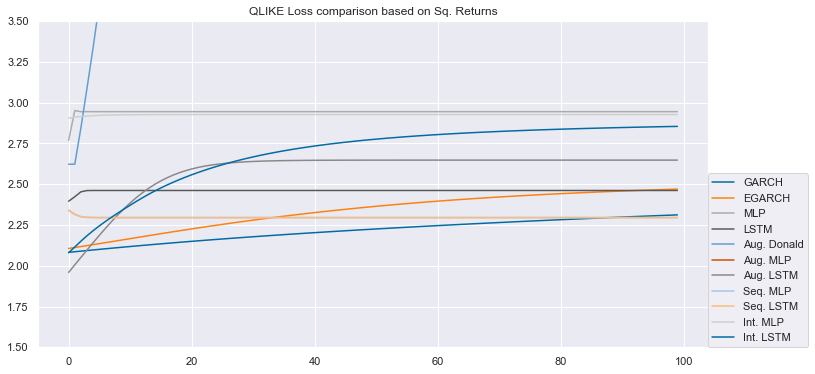

In [132]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.title("QLIKE Loss comparison based on Sq. Returns")
plt.plot(garch_origin_qlikes_rsq, label = "GARCH")
plt.plot(egarch_origin_qlikes_rsq, label = "EGARCH")
plt.plot(mlp_qlikes_rsq, label = "MLP")
plt.plot(lstm_qlikes_rsq, label = "LSTM")
plt.plot(aug_don_qlikes_rsq, label = "Aug. Donald")
plt.plot(aug_mlp_qlikes_rsq, label = "Aug. MLP")
plt.plot(aug_lstm_qlikes_rsq, label = "Aug. LSTM")
plt.plot(seq_mlp_qlikes_rsq, label = "Seq. MLP")
plt.plot(seq_lstm_qlikes_rsq, label = "Seq. LSTM")
plt.plot(int_mlp_qlikes_rsq, label = "Int. MLP")
plt.plot(int_lstm_qlikes_rsq, label = "Int. LSTM")
plt.legend(loc=(1,0))
plt.ylim(1.5,3.5)
plt.savefig(path + "Plots/DataApp/Preds/all_multistep_compared_preds_sqr.png")

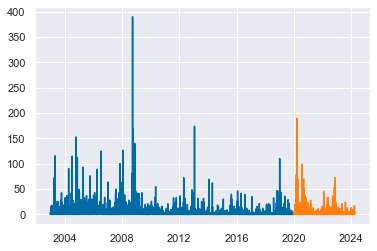

In [299]:
plt.plot(train_sq_returns)
plt.plot(test_sq_returns)

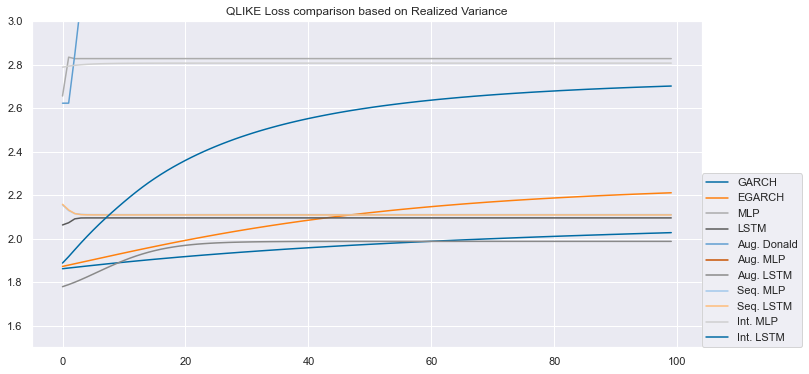

In [134]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.title("QLIKE Loss comparison based on Realized Variance")
plt.plot(garch_origin_qlikes_rv, label = "GARCH")
plt.plot(egarch_origin_qlikes_rv, label = "EGARCH")
plt.plot(mlp_qlikes_rv, label = "MLP")
plt.plot(lstm_qlikes_rv, label = "LSTM")
plt.plot(aug_don_qlikes_rsq, label = "Aug. Donald")
plt.plot(aug_mlp_qlikes_rv, label = "Aug. MLP")
plt.plot(aug_lstm_qlikes_rv, label = "Aug. LSTM")
plt.plot(seq_mlp_qlikes_rv, label = "Seq. MLP")
plt.plot(seq_lstm_qlikes_rv, label = "Seq. LSTM")
plt.plot(int_mlp_qlikes_rv, label = "Int. MLP")
plt.plot(int_lstm_qlikes_rv, label = "Int. LSTM")
plt.legend(loc=(1,0))
plt.ylim(1.5,3)
plt.savefig(path + "Plots/DataApp/Preds/all_multistep_compared_preds_rv.png")

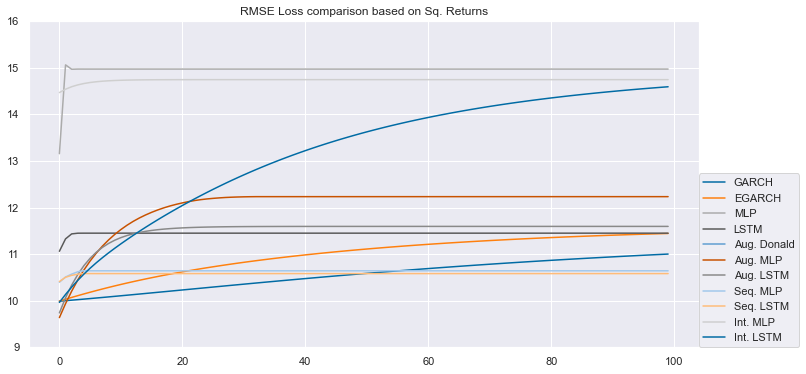

In [142]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.title("RMSE Loss comparison based on Sq. Returns")
plt.plot(garch_origin_rmse_rsq, label = "GARCH")
plt.plot(egarch_origin_rmse_rsq, label = "EGARCH")
plt.plot(mlp_rmse_rsq, label = "MLP")
plt.plot(lstm_rmse_rsq, label = "LSTM")
plt.plot(aug_don_rmse_rsq, label = "Aug. Donald")
plt.plot(aug_mlp_rmse_rsq, label = "Aug. MLP")
plt.plot(aug_lstm_rmse_rsq, label = "Aug. LSTM")
plt.plot(seq_mlp_rmse_rsq, label = "Seq. MLP")
plt.plot(seq_lstm_rmse_rsq, label = "Seq. LSTM")
plt.plot(int_mlp_rmse_rsq, label = "Int. MLP")
plt.plot(int_lstm_rmse_rsq, label = "Int. LSTM")
plt.legend(loc=(1,0))
plt.ylim(9,16)
plt.savefig(path + "Plots/DataApp/Preds/all_multistep_compared_preds_rmse_sqr.png")

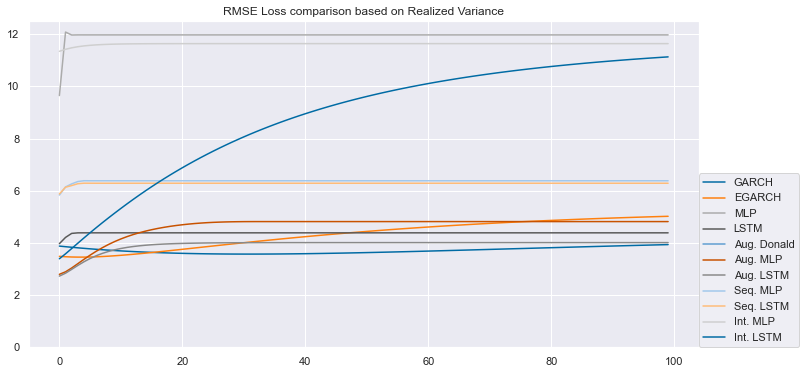

In [143]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,6))
plt.title("RMSE Loss comparison based on Realized Variance")
plt.plot(garch_origin_rmse_rv, label = "GARCH")
plt.plot(egarch_origin_rmse_rv, label = "EGARCH")
plt.plot(mlp_rmse_rv, label = "MLP")
plt.plot(lstm_rmse_rv, label = "LSTM")
plt.plot(aug_don_rmse_rv, label = "Aug. Donald")
plt.plot(aug_mlp_rmse_rv, label = "Aug. MLP")
plt.plot(aug_lstm_rmse_rv, label = "Aug. LSTM")
plt.plot(seq_mlp_rmse_rv, label = "Seq. MLP")
plt.plot(seq_lstm_rmse_rv, label = "Seq. LSTM")
plt.plot(int_mlp_rmse_rv, label = "Int. MLP")
plt.plot(int_lstm_rmse_rv, label = "Int. LSTM")
plt.legend(loc=(1,0))
plt.ylim(0,12.5)
plt.savefig(path + "Plots/DataApp/Preds/all_multistep_compared_preds_rmse_rv.png")

In [209]:
df_all_preds

,GARCH,EGARCH,MLP,LSTM,Aug. Donaldson,Aug. MLP,Aug. LSTM,Seq. MLP,Seq. LSTM,Int. MLP,Int. LSTM
Date,,,,,,,,,,,
2019-12-27,1.931718,1.581987,9.642678,4.438264,1.437554,3.045426,3.411786,4.552121,4.569321,13.251256,2.051798
2019-12-30,1.851431,1.481341,9.940459,4.379340,1.444409,2.131723,2.843940,4.565096,4.573612,13.245057,1.952672
2019-12-31,1.798701,1.428278,10.111810,4.381333,2.079424,1.496653,2.476259,4.587040,4.588675,13.241623,1.882436
2020-01-02,1.761044,1.390114,13.641280,4.382551,2.413253,1.712135,2.798619,4.575035,4.580258,13.270356,2.265512
2020-01-03,2.006479,1.481280,10.536490,4.492778,10.949261,1.252022,2.500447,4.597198,4.596088,13.266692,2.237693
...,...,...,...,...,...,...,...,...,...,...,...
2024-03-21,1.935762,2.334169,13.810276,4.399228,5.405462,2.554804,3.833620,4.606731,4.603256,13.386092,2.952848
2024-03-22,2.924560,3.676691,9.879909,8.455877,34.286659,1.764692,3.125157,4.651879,4.639432,13.342864,2.442264
2024-03-25,2.785681,3.414931,10.273890,4.380893,1.950331,1.255154,2.691573,4.705137,4.685561,13.317253,2.146557


In [208]:
df_all_preds = pd.DataFrame([garch_one_step_preds,
              egarch_one_step_preds,
              n_step_preds_mlp["h.001"],
              lstm_n_step_preds["h.001"],
              n_step_preds_aug_donald["h.001"],
              n_step_preds_aug_ext_mlp["h.001"],
              n_step_preds_aug_ext_lstm["h.001"],
              seq_mlp_multi_step_preds["h.001"], 
              seq_lstm_multi_step_preds["h.001"],
              int_mlp_n_step_preds[0], 
              n_step_int_lstm_preds["h.001"]]).T


all_model_names =  ["GARCH",
                    "EGARCH",
                    "MLP",
                    "LSTM",
                    "Aug. Donaldson",
                    "Aug. MLP",
                    "Aug. LSTM",
                    "Seq. MLP",
                    "Seq. LSTM",
                    "Int. MLP",
                    "Int. LSTM"]

df_all_preds.columns = all_model_names

df_all_preds.dropna(inplace = True)
corr_preds = df_all_preds.select_dtypes('number').corr()

In [210]:
corr_preds

,GARCH,EGARCH,MLP,LSTM,Aug. Donaldson,Aug. MLP,Aug. LSTM,Seq. MLP,Seq. LSTM,Int. MLP,Int. LSTM
GARCH,1.000000,0.958650,0.179644,0.487493,0.512630,0.816358,0.765815,0.735501,0.729131,0.787499,0.819837
EGARCH,0.958650,1.000000,0.195810,0.509950,0.537161,0.840421,0.795580,0.684662,0.678704,0.816038,0.859220
MLP,0.179644,0.195810,1.000000,0.086732,0.075785,0.256126,0.251645,0.146317,0.144518,0.221635,0.304700
LSTM,0.487493,0.509950,0.086732,1.000000,0.955726,0.644189,0.648434,0.433009,0.430039,0.643482,0.555681
Aug. Donaldson,0.512630,0.537161,0.075785,0.955726,1.000000,0.682223,0.698427,0.426655,0.423238,0.693721,0.596201
Aug. MLP,0.816358,0.840421,0.256126,0.644189,0.682223,1.000000,0.992817,0.731377,0.726229,0.993053,0.890759
Aug. LSTM,0.765815,0.795580,0.251645,0.648434,0.698427,0.992817,1.000000,0.680199,0.675149,0.997486,0.878279
Seq. MLP,0.735501,0.684662,0.146317,0.433009,0.426655,0.731377,0.680199,1.000000,0.999586,0.693152,0.621794
Seq. LSTM,0.729131,0.678704,0.144518,0.430039,0.423238,0.726229,0.675149,0.999586,1.000000,0.688083,0.615653
Int. MLP,0.787499,0.816038,0.221635,0.643482,0.693721,0.993053,0.997486,0.693152,0.688083,1.000000,0.876414


In [211]:
all_preds_desc = np.round(df_all_preds.describe(),4).T
all_preds_desc.drop("count", axis = 1, inplace = True)
all_preds_desc

,mean,std,min,25%,50%,75%,max
GARCH,4.3411,4.0968,1.3834,2.1818,3.2692,4.7936,37.1307
EGARCH,4.3964,3.5913,1.3589,2.4276,3.4848,5.0629,36.2071
MLP,11.3988,1.6900,8.3081,9.8338,10.6450,13.5448,14.1481
LSTM,4.8952,1.7776,4.3793,4.3806,4.3869,4.4459,24.4044
Aug. Donaldson,9.5413,21.5570,1.4376,1.8603,3.4739,9.1770,358.4194
Aug. MLP,1.8349,3.2944,0.0000,0.2638,0.8256,2.0850,43.5140
Aug. LSTM,3.0650,2.4986,1.5007,1.9725,2.4200,3.2351,38.9681
Seq. MLP,6.4952,4.9333,4.5515,4.6225,4.8876,5.7413,24.8072
Seq. LSTM,6.5196,4.9687,4.5672,4.6171,4.8782,5.6880,24.8072
Int. MLP,13.3427,0.1997,13.2291,13.2593,13.2898,13.3505,16.1784


In [218]:
print(all_preds_desc.to_latex(
                  formatters={"name": str.upper},
                  float_format="{:.2f}".format))

\begin{tabular}{lrrrrrrr}
\toprule
{} &  mean &   std &   min &   25\% &   50\% &   75\% &    max \\
\midrule
GARCH          &  4.34 &  4.10 &  1.38 &  2.18 &  3.27 &  4.79 &  37.13 \\
EGARCH         &  4.40 &  3.59 &  1.36 &  2.43 &  3.48 &  5.06 &  36.21 \\
MLP            & 11.40 &  1.69 &  8.31 &  9.83 & 10.64 & 13.54 &  14.15 \\
LSTM           &  4.90 &  1.78 &  4.38 &  4.38 &  4.39 &  4.45 &  24.40 \\
Aug. Donaldson &  9.54 & 21.56 &  1.44 &  1.86 &  3.47 &  9.18 & 358.42 \\
Aug. MLP       &  1.83 &  3.29 &  0.00 &  0.26 &  0.83 &  2.08 &  43.51 \\
Aug. LSTM      &  3.06 &  2.50 &  1.50 &  1.97 &  2.42 &  3.24 &  38.97 \\
Seq. MLP       &  6.50 &  4.93 &  4.55 &  4.62 &  4.89 &  5.74 &  24.81 \\
Seq. LSTM      &  6.52 &  4.97 &  4.57 &  4.62 &  4.88 &  5.69 &  24.81 \\
Int. MLP       & 13.34 &  0.20 & 13.23 & 13.26 & 13.29 & 13.35 &  16.18 \\
Int. LSTM      &  4.32 &  2.77 &  1.15 &  2.21 &  4.13 &  5.57 &  34.50 \\
\bottomrule
\end{tabular}



/var/folders/hv/0fbbgwqj67sdm29fqsqv9bv80000gn/T/ipykernel_75349/2771152770.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(all_preds_desc.to_latex(


In [290]:
df_all_preds100 = pd.DataFrame([garch_preds_origin.loc[test_index,"h.100"],
              egarch_preds_origin.loc[test_index,"h.100"],
              n_step_preds_mlp["h.100"],
              lstm_n_step_preds["h.100"],
              n_step_preds_aug_donald["h.100"],
              n_step_preds_aug_ext_mlp["h.100"],
              n_step_preds_aug_ext_lstm["h.100"],
              seq_mlp_multi_step_preds["h.100"], 
              seq_lstm_multi_step_preds["h.100"],
              int_mlp_n_step_preds[99], 
              n_step_int_lstm_preds["h.100"]]).T

all_model_names =  ["GARCH",
                    "EGARCH",
                    "MLP",
                    "LSTM",
                    "Aug. Donaldson",
                    "Aug. MLP",
                    "Aug. LSTM",
                    "Seq. MLP",
                    "Seq. LSTM",
                    "Int. MLP",
                    "Int. LSTM"]

df_all_preds100.columns = all_model_names

df_all_preds100.dropna(inplace = True)
corr_preds100 = df_all_preds100.select_dtypes('number').corr()
corr_preds100

,GARCH,EGARCH,MLP,LSTM,Aug. Donaldson,Aug. MLP,Aug. LSTM,Seq. MLP,Seq. LSTM,Int. MLP,Int. LSTM
GARCH,1.000000,0.826954,NaN,NaN,-0.022976,NaN,0.453626,0.721922,0.724658,0.682130,0.146951
EGARCH,0.826954,1.000000,NaN,NaN,0.007486,NaN,0.630904,0.618981,0.615828,0.510908,0.423804
MLP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSTM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aug. Donaldson,-0.022976,0.007486,NaN,NaN,1.000000,NaN,0.071908,0.075794,0.071347,-0.002350,0.051932
Aug. MLP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aug. LSTM,0.453626,0.630904,NaN,NaN,0.071908,NaN,1.000000,0.339325,0.333680,0.229026,0.293889
Seq. MLP,0.721922,0.618981,NaN,NaN,0.075794,NaN,0.339325,1.000000,0.983365,0.659434,-0.021683
Seq. LSTM,0.724658,0.615828,NaN,NaN,0.071347,NaN,0.333680,0.983365,1.000000,0.670639,-0.027246
Int. MLP,0.682130,0.510908,NaN,NaN,-0.002350,NaN,0.229026,0.659434,0.670639,1.000000,-0.111725


# DMW-Test

In [262]:
from dieboldmariano import dm_test

-2.2229922805746782 0.04515565862099125


In [269]:
# Test if Augmented model with LSTM specification is better than GARCH:
print("Sq.Ret.: ",dm_test(test_sq_returns, df_all_preds["Aug. LSTM"], df_all_preds["GARCH"],one_sided=True, h = 1))
print("RV: ",dm_test(test_rv, df_all_preds["Aug. LSTM"], df_all_preds["GARCH"],one_sided=True, h = 1))
# H0 of equal forecasts are rejected

Sq.Ret.:  (-3.796640959143593, 7.746269557877632e-05)
RV:  (-5.735061448429176, 6.3408554838970895e-09)


In [295]:
print(dm_test(test_sq_returns, df_all_preds100["Aug. LSTM"], df_all_preds100["GARCH"],one_sided=False, h = 100,harvey_correction=True))
print(dm_test(test_rv, df_all_preds100["Aug. LSTM"], df_all_preds100["GARCH"],one_sided=False, h = 100,harvey_correction=True))

(1.1183340593285764, 0.2636758263080512)
(0.15159349490272112, 0.8795361939986989)


In [297]:
print(dm_test(test_sq_returns, df_all_preds100["Seq. LSTM"], df_all_preds100["GARCH"],one_sided=False, h = 100,harvey_correction=True))

(-0.6662768505171676, 0.505378051443534)


In [ ]:
stat, pval = dm_test(T, F, G, one_sided=True)
print(stat, pval)

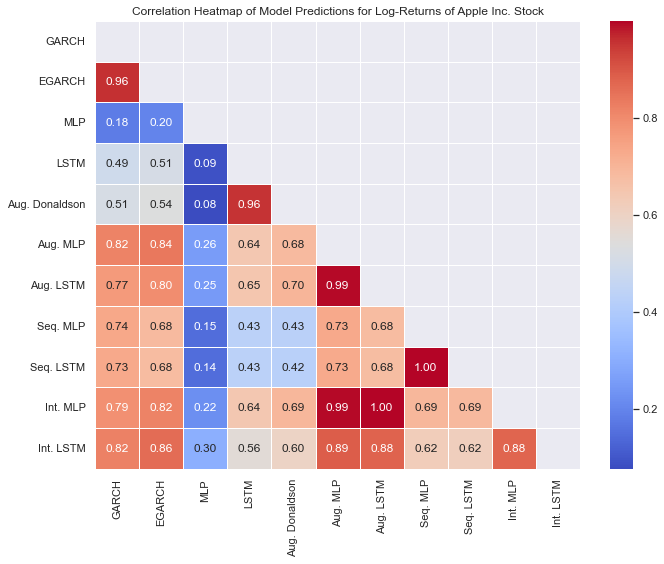

In [217]:
matrix = np.triu(corr_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_preds, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, mask = matrix)
plt.title(f"Correlation Heatmap of Model Predictions for Log-Returns of Apple Inc. Stock")
plt.tight_layout()
plt.savefig(f'/Users/akirasohejl/Desktop/Humboldt Universität/Master Arbeit/Code/Plots/DataApp/preds_corr.png')
plt.show()

In [ ]:
all_model_parameters = pd.concat([garch_parameters,
                                   egarch_parameters,
                                   aug_donaldson_parameters,
                                   aug_extended_mlp_parameters,
                                   aug_extended_lstm_parameters,
                                   seq_denoised_mlp_params,
                                   seq_denoised_lstm_params,
                                   int_mlp_parameters,
                                   int_lstm_parameters])

all_model_parameters.insert(0, "Model", ["GARCH",
                                        "EGARCH",
                                        "AUG_DONALDSON",
                                        "AUG_MLP",
                                        "AUG_LSTM",
                                        "SEQ_DENOISE_MLP",
                                        "SEQ_DENOISE_LSTM",
                                        "INT_MLP",
                                        "INT_LSTM"])
all_model_parameters.to_excel(path + f"Results/DataApp_all_model_parms.xlsx")
print(all_model_parameters.to_latex(index=False,
                  formatters={"name": str.upper},
                  float_format="{:.4f}".format))

In [ ]:
pd.DataFrame([fc_metrics_garch])

In [ ]:
df_fc_metrics_all = pd.concat([fc_metrics_garch,
                               fc_metrics_egarch,
                               fc_metrics_mlp,
                               fc_metrics_lstm,
                               fc_metrics_aug_donald,
                               fc_metrics_aug_extended_mlp,
                               fc_metrics_aug_extended_lstm,
                               fc_metrics_seq_denoise_mlp,
                               fc_metrics_seq_denoise_lstm,
                               fc_metrics_seq_resid_mlp,
                               fc_metrics_seq_resid_lstm,
                               fc_metrics_int_mlp,
                               fc_metrics_int_lstm])
df_fc_metrics_all.columns = ['Model', "RMSE","MAPE","MAE","QLIKE Loss"]
df_fc_metrics_all.to_excel(path + f"Results/DataApp_forecast_metrics_aapl.xlsx")
df_fc_metrics_all

In [ ]:
print(df_fc_metrics_all.to_latex(index=False,
                  formatters={"name": str.upper},
                  float_format="{:.6}".format))

In [ ]:
models = ["nn_mlp",
          "nn_lstm",
          "aug_donald",
          "aug_extended_mlp",
          "aug_extended_lstm",
          "seq_denoise_mlp",
          "seq_denoise_lstm",
          "seq_resid_mlp",
          "seq_resid_lstm",
          "integ_mlp",
          "integ_lstm"]

model_losses = {}
for m in models:
    model_losses[m] = pd.read_csv(path+f"Plots/DataApp/Loss/{m}_loss_history.csv",header= None,names = ["NN: MLP"])
model_losses

In [ ]:
plt.plot(model_losses["nn_mlp"], label = "NN: MLP")
plt.plot(model_losses["nn_lstm"], label = "NN: LSTM")
plt.legend()
plt.ylabel("MSE")
plt.xlabel("Epochs")

In [ ]:
plt.plot(model_losses["aug_donald"], label = "Augmented: Donaldson")
plt.plot(model_losses["aug_extended_mlp"], label = "Augmented: MLP")
plt.plot(model_losses["aug_extended_lstm"], label = "Augmented: LSTM")
plt.legend()
plt.ylabel("NLL")
plt.xlabel("Epochs")

In [ ]:
plt.plot(model_losses["seq_denoise_mlp"], label = "Sequential: Denoise (MLP)")
plt.plot(model_losses["seq_denoise_lstm"], label = "Sequential: Denoise (LSTM)")
#plt.plot(model_losses["seq_resid_mlp"], label = "Sequential: Residual (MLP)")
#plt.plot(model_losses["seq_resid_lstm"], label = "Sequential: Residual (LSTM)")
plt.legend()
plt.ylabel("MSE")
plt.xlabel("Epochs")

In [ ]:
#plt.plot(model_losses["seq_denoise_mlp"], label = "Sequential: Denoise (MLP)")
#plt.plot(model_losses["seq_denoise_lstm"], label = "Sequential: Denoise (LSTM)")
plt.plot(model_losses["seq_resid_mlp"], label = "Sequential: Residual (MLP)")
plt.plot(model_losses["seq_resid_lstm"], label = "Sequential: Residual (LSTM)")
plt.legend()
plt.ylabel("MSE")
plt.xlabel("Epochs")

In [ ]:
plt.plot(model_losses["integ_mlp"], label = "Integrated: MLP")
plt.plot(model_losses["integ_lstm"], label = "Integrated: LSTM")
plt.legend()
plt.ylabel("NLL")
plt.xlabel("Epochs")